# ML Project Customer Categorizer

- Downloading dataset to use.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "maharshipandya/-cryptocurrency-historical-prices-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 3.29M/3.29M [00:00<00:00, 108MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/maharshipandya/-cryptocurrency-historical-prices-dataset/versions/1


In [2]:
import os
import pandas as pd

print("Files in dataset folder:")

for file in os.listdir(path):
    print(file)

Files in dataset folder:
dataset.csv


Loading the CSV

In [3]:
csv_files = [
    file for file in os.listdir(path)
    if file.lower().endswith(".csv")
]

print("CSV files:", csv_files)

CSV files: ['dataset.csv']


In [4]:
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

   Unnamed: 0        open        high         low       close  volume  \
0           0  112.900002  118.800003  107.142998  115.910004     0.0   
1           1    3.493130    3.692460    3.346060    3.590890     0.0   
2           2  115.980003  124.663002  106.639999  112.300003     0.0   
3           3    3.594220    3.781020    3.116020    3.371250     0.0   
4           4  112.250000  113.444000   97.699997  111.500000     0.0   

      marketCap                 timestamp crypto_name        date  
0  1.288693e+09  2013-05-05T23:59:59.999Z     Bitcoin  2013-05-05  
1  6.229819e+07  2013-05-05T23:59:59.999Z    Litecoin  2013-05-05  
2  1.249023e+09  2013-05-06T23:59:59.999Z     Bitcoin  2013-05-06  
3  5.859436e+07  2013-05-06T23:59:59.999Z    Litecoin  2013-05-06  
4  1.240594e+09  2013-05-07T23:59:59.999Z     Bitcoin  2013-05-07  

Shape: (72946, 10)

Columns:
['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp', 'crypto_name', 'date']

Missing values:


In [5]:
print(df.head())
print(df.shape)
print(df.columns.tolist())

   Unnamed: 0        open        high         low       close  volume  \
0           0  112.900002  118.800003  107.142998  115.910004     0.0   
1           1    3.493130    3.692460    3.346060    3.590890     0.0   
2           2  115.980003  124.663002  106.639999  112.300003     0.0   
3           3    3.594220    3.781020    3.116020    3.371250     0.0   
4           4  112.250000  113.444000   97.699997  111.500000     0.0   

      marketCap                 timestamp crypto_name        date  
0  1.288693e+09  2013-05-05T23:59:59.999Z     Bitcoin  2013-05-05  
1  6.229819e+07  2013-05-05T23:59:59.999Z    Litecoin  2013-05-05  
2  1.249023e+09  2013-05-06T23:59:59.999Z     Bitcoin  2013-05-06  
3  5.859436e+07  2013-05-06T23:59:59.999Z    Litecoin  2013-05-06  
4  1.240594e+09  2013-05-07T23:59:59.999Z     Bitcoin  2013-05-07  
(72946, 10)
['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp', 'crypto_name', 'date']


preparation of the data

In [55]:
df = df.rename(columns={
    "crypto_name": "symbol",
    "marketCap": "market_cap"
})

df = df.drop(columns=["Unnamed: 0", "timestamp"])

KeyError: "['Unnamed: 0', 'timestamp'] not found in axis"

In [54]:
print(df["crypto_name"].nunique())
print(df["crypto_name"].value_counts().head(20))

print("\nMissing values:")
print(df.isnull().sum())

print("\nZero volume:")
print((df["volume"] == 0).sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

KeyError: 'crypto_name'

crypto_name is no longer a column in current df

In [13]:
print(df.columns.tolist())


['open', 'high', 'low', 'close', 'volume', 'market_cap', 'symbol', 'date']


Pandas now has symbol instead of crypto_name

In [16]:
print("Number of cryptocurrencies:", df["symbol"].nunique())
print("\nCryptocurrency counts:")
print(df["symbol"].value_counts().head(20))

print("\nMissing values:")
print(df.isnull().sum())

print("\nZero volume:")
print((df["volume"] == 0).sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Number of cryptocurrencies: 56

Cryptocurrency counts:
symbol
Bitcoin                  3248
Litecoin                 3248
XRP                      3157
Dogecoin                 3024
Monero                   2866
Stellar                  2791
Tether                   2582
Ethereum                 2424
Ethereum Classic         2072
Basic Attention Token    1760
EOS                      1730
Bitcoin Cash             1708
BNB                      1706
TRON                     1656
Decentraland             1652
Chainlink                1649
Cardano                  1638
Maker                    1605
Filecoin                 1565
Theta Network            1530
Name: count, dtype: int64

Missing values:
open          0
high          0
low           0
close         0
volume        0
market_cap    0
symbol        0
date          0
dtype: int64

Zero volume:
688

Date range:
2013-05-05 to 2022-10-23


# Converting date to datetime before doing the year analysis.

In [18]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check the data type
print(df["date"].dtype)

datetime64[ns]


The zero-volume analysis

In [19]:
# Select zero-volume records
zero_volume = df[df["volume"] == 0].copy()

print("Number of zero-volume records:", len(zero_volume))

print("\nZero-volume records by cryptocurrency:")
print(zero_volume["symbol"].value_counts())

print("\nZero-volume records by year:")
print(
    zero_volume["date"]
    .dt.year
    .value_counts()
    .sort_index()
)

print("\nSample zero-volume records:")
print(zero_volume.head())

Number of zero-volume records: 688

Zero-volume records by cryptocurrency:
symbol
Bitcoin      236
Litecoin     236
XRP          145
Shiba Inu     40
THORChain     15
Dogecoin      12
Aave           4
Name: count, dtype: int64

Zero-volume records by year:
date
2013    629
2019     15
2020     36
2021      8
Name: count, dtype: int64

Sample zero-volume records:
         open        high         low       close  volume    market_cap  \
0  112.900002  118.800003  107.142998  115.910004     0.0  1.288693e+09   
1    3.493130    3.692460    3.346060    3.590890     0.0  6.229819e+07   
2  115.980003  124.663002  106.639999  112.300003     0.0  1.249023e+09   
3    3.594220    3.781020    3.116020    3.371250     0.0  5.859436e+07   
4  112.250000  113.444000   97.699997  111.500000     0.0  1.240594e+09   

     symbol       date  
0   Bitcoin 2013-05-05  
1  Litecoin 2013-05-05  
2   Bitcoin 2013-05-06  
3  Litecoin 2013-05-06  
4   Bitcoin 2013-05-07  


In [20]:
# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Sort data separately by cryptocurrency and date
df = df.sort_values(
    ["symbol", "date"]
).reset_index(drop=True)

# Check everything
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Dataset shape: (72946, 8)

Data types:
open                 float64
high                 float64
low                  float64
close                float64
volume               float64
market_cap           float64
symbol                object
date          datetime64[ns]
dtype: object

Missing values:
open          0
high          0
low           0
close         0
volume        0
market_cap    0
symbol        0
date          0
dtype: int64

Date range:
2013-05-05 00:00:00 to 2022-10-23 00:00:00


1. Basic statistical analysis

In [21]:
# Basic statistical summary
print(df.describe())

               open          high           low         close        volume  \
count  72946.000000  7.294600e+04  72946.000000  7.294600e+04  7.294600e+04   
mean     870.194495  8.964124e+02    844.060640  8.712949e+02  2.207607e+09   
min        0.000000  1.022100e-10      0.000000  8.292000e-11  0.000000e+00   
25%        0.167916  1.767999e-01      0.158630  1.682982e-01  8.320618e+06   
50%        1.630666  1.717542e+00      1.541486  1.640219e+00  1.098756e+08   
75%       26.070557  2.756868e+01     24.791776  2.625195e+01  6.691398e+08   
max    67549.735581  1.621883e+05  66458.723733  6.756683e+04  3.509679e+11   
std     5231.654470  5.398613e+03   5079.389387  5.235508e+03  9.617885e+09   

         market_cap                           date  
count  7.294600e+04                          72946  
mean   1.474922e+10  2019-10-13 03:20:59.945713152  
min    0.000000e+00            2013-05-05 00:00:00  
25%    1.860432e+08            2018-09-08 00:00:00  
50%    1.268539e+09    

The number of observations for each cryptocurrency:

In [22]:
print("\nNumber of records for each cryptocurrency:")
print(df["symbol"].value_counts())


Number of records for each cryptocurrency:
symbol
Bitcoin                  3248
Litecoin                 3248
XRP                      3157
Dogecoin                 3024
Monero                   2866
Stellar                  2791
Tether                   2582
Ethereum                 2424
Ethereum Classic         2072
Basic Attention Token    1760
EOS                      1730
Bitcoin Cash             1708
BNB                      1706
TRON                     1656
Decentraland             1652
Chainlink                1649
Cardano                  1638
Maker                    1605
Filecoin                 1565
Theta Network            1530
Huobi Token              1513
Ravencoin                1478
Tezos                    1365
VeChain                  1332
Quant                    1325
USD Coin                 1266
Cronos                   1199
Wrapped Bitcoin          1152
Cosmos                   1109
Polygon                  1064
OKB                      1062
UNUS SED LEO       

2. Current-day volatility for EDA

For visualization, we'll use:

$$ Volatility = \frac{High-Low}{Close} $$

In [23]:
# Calculate daily volatility for EDA
df["volatility"] = (df["high"] - df["low"]) / df["close"]

print(df["volatility"].describe())

count    72946.000000
mean         0.086374
std          0.139016
min          0.000000
25%          0.036775
50%          0.064117
75%          0.106861
max         17.851150
Name: volatility, dtype: float64


3. Plot Bitcoin price over time

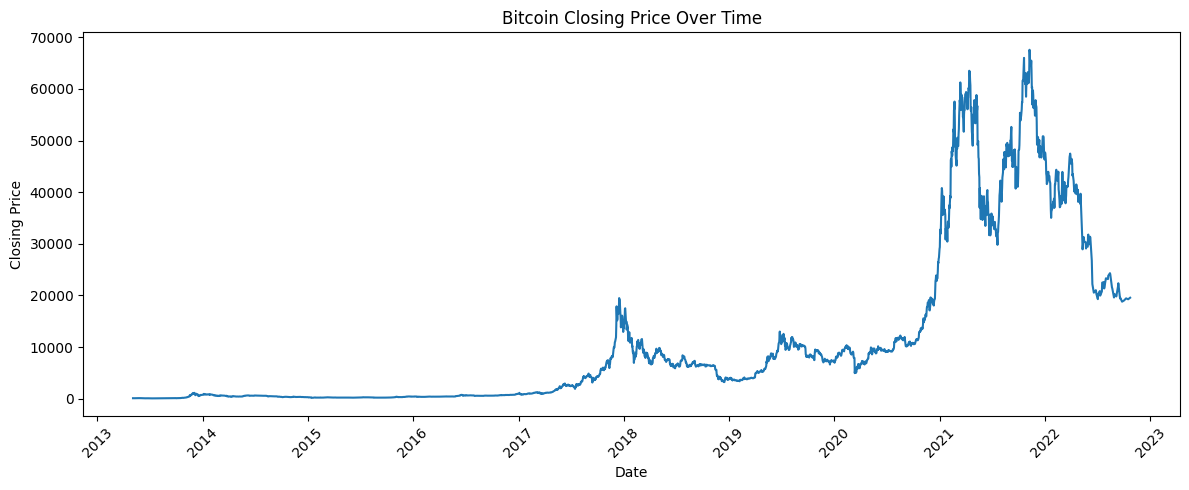

In [24]:
import matplotlib.pyplot as plt

bitcoin = df[df["symbol"] == "Bitcoin"].copy()

plt.figure(figsize=(12, 5))
plt.plot(bitcoin["date"], bitcoin["close"])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A useful EDA figure for your report showing how Bitcoin's price changed from 2013–2022.

4. Plot Bitcoin volatility

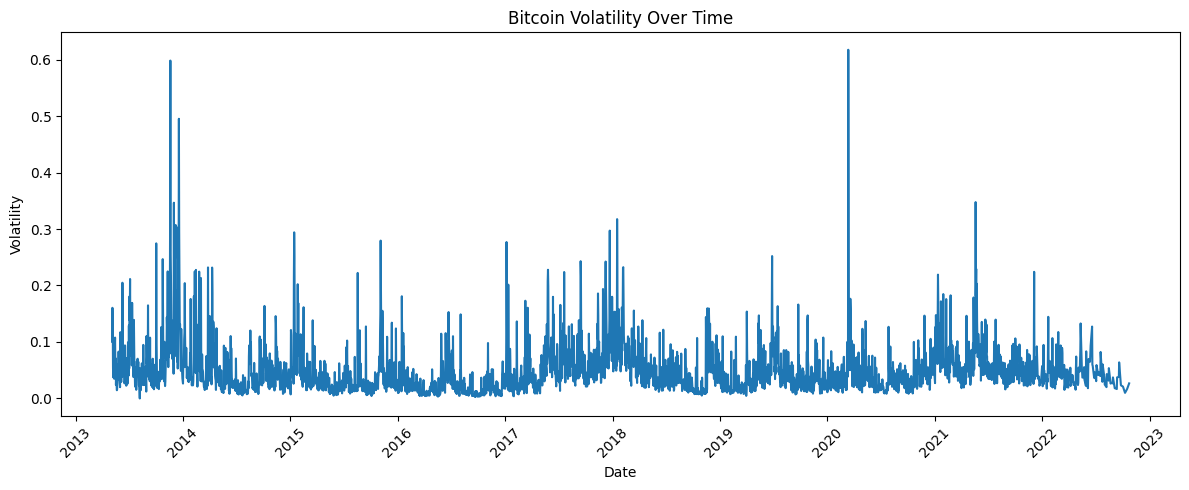

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(bitcoin["date"], bitcoin["volatility"])
plt.title("Bitcoin Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Volatility distribution

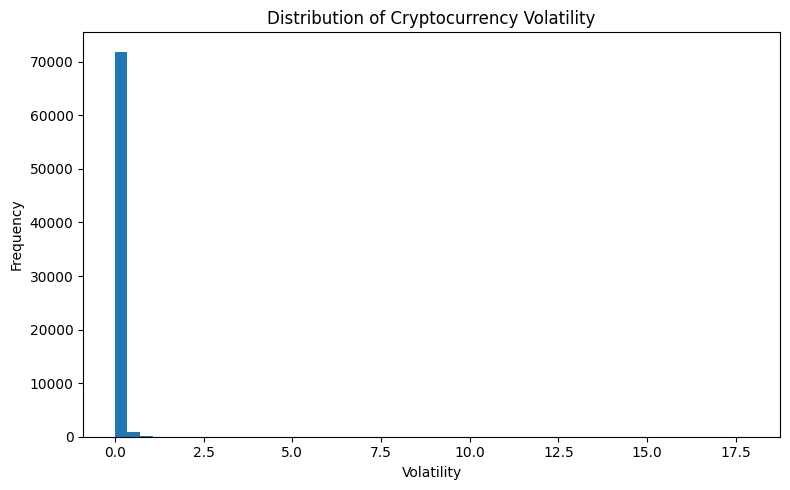

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df["volatility"].dropna(), bins=50)
plt.title("Distribution of Cryptocurrency Volatility")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

6. Volume distribution

Because cryptocurrency volume can have very large values, a logarithmic transformation makes the distribution easier to inspect:

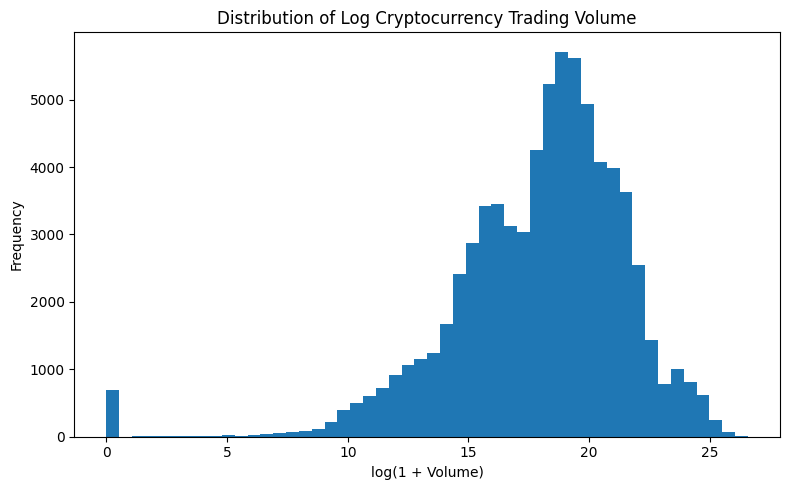

In [27]:
import numpy as np

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["volume"]), bins=50)
plt.title("Distribution of Log Cryptocurrency Trading Volume")
plt.xlabel("log(1 + Volume)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

7. Correlation analysis

For the numerical variables:

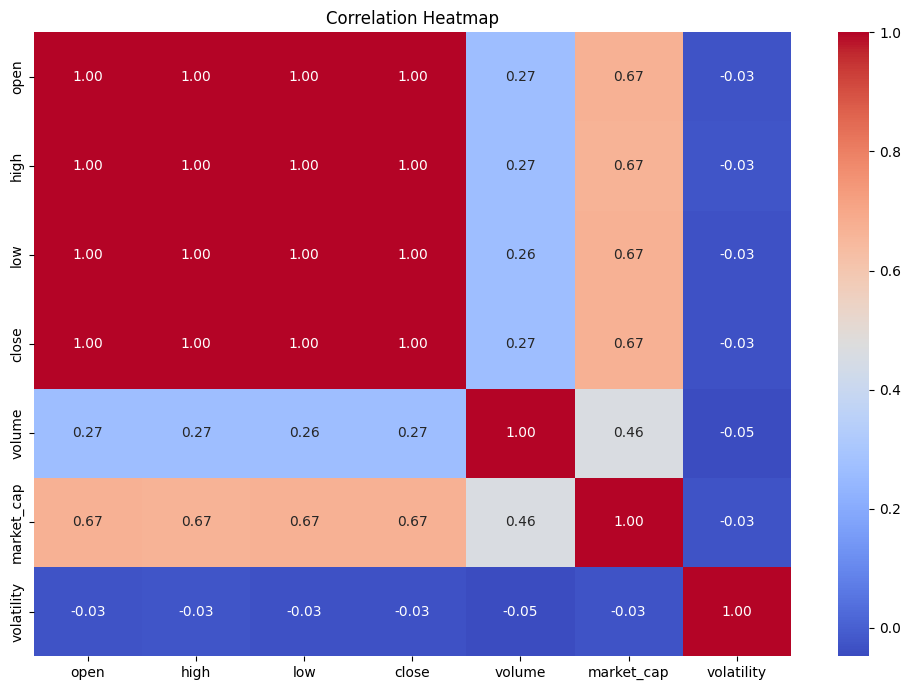

In [28]:
import seaborn as sns

numeric_cols = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "market_cap",
    "volatility"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

8. Compare volatility across cryptocurrencies

Let's identify the cryptocurrencies with the highest average observed volatility:

In [29]:
volatility_by_crypto = (
    df.groupby("symbol")["volatility"]
    .mean()
    .sort_values(ascending=False)
)

print(volatility_by_crypto.head(10))

symbol
Shiba Inu            0.216054
ApeCoin              0.178403
Filecoin             0.149678
THORChain            0.140943
The Sandbox          0.135697
Quant                0.135372
Aptos                0.134731
Terra Classic        0.124441
NEAR Protocol        0.124104
Internet Computer    0.123656
Name: volatility, dtype: float64


And the lowest:

In [30]:
print(volatility_by_crypto.tail(10))

symbol
Litecoin           0.069442
FTX Token          0.065790
Huobi Token        0.064417
Wrapped Bitcoin    0.058958
Bitcoin            0.049302
UNUS SED LEO       0.039710
Dai                0.015298
USD Coin           0.010819
Tether             0.010046
Binance USD        0.008305
Name: volatility, dtype: float64


1. Feature engineering

In [32]:
import numpy as np
import pandas as pd

# Make a fresh copy and ensure correct order
df_model = df.copy()

df_model["date"] = pd.to_datetime(df_model["date"])
df_model = df_model.sort_values(
    ["symbol", "date"]
).reset_index(drop=True)

# Current-day volatility
df_model["current_volatility"] = (
    (df_model["high"] - df_model["low"]) / df_model["close"]
)

# Group by cryptocurrency for time-based calculations
group = df_model.groupby("symbol", group_keys=False)

# 1. Daily return
df_model["daily_return"] = group["close"].pct_change()

# 2. Moving averages
df_model["MA_7"] = group["close"].transform(
    lambda x: x.rolling(7).mean()
)

df_model["MA_30"] = group["close"].transform(
    lambda x: x.rolling(30).mean()
)

# 3. Rolling volatility
df_model["rolling_volatility_7"] = group["daily_return"].transform(
    lambda x: x.rolling(7).std()
)

df_model["rolling_volatility_30"] = group["daily_return"].transform(
    lambda x: x.rolling(30).std()
)

# 4. Liquidity ratio
df_model["liquidity_ratio"] = np.where(
    df_model["market_cap"] > 0,
    df_model["volume"] / df_model["market_cap"],
    np.nan
)

# 5. Bollinger Bands (20-day window)
df_model["BB_middle"] = group["close"].transform(
    lambda x: x.rolling(20).mean()
)

rolling_std_20 = group["close"].transform(
    lambda x: x.rolling(20).std()
)

df_model["BB_upper"] = df_model["BB_middle"] + 2 * rolling_std_20
df_model["BB_lower"] = df_model["BB_middle"] - 2 * rolling_std_20

# 6. Average True Range (ATR)
previous_close = group["close"].shift(1)

tr1 = df_model["high"] - df_model["low"]
tr2 = (df_model["high"] - previous_close).abs()
tr3 = (df_model["low"] - previous_close).abs()

df_model["true_range"] = pd.concat(
    [tr1, tr2, tr3],
    axis=1
).max(axis=1)

df_model["ATR_14"] = group["true_range"].transform(
    lambda x: x.rolling(14).mean()
)

# 7. Target: next available record's volatility for the same coin
df_model["target_volatility"] = group["current_volatility"].shift(-1)

# Replace infinite values and remove rows without required history/target
df_model = df_model.replace([np.inf, -np.inf], np.nan)

df_model = df_model.dropna().reset_index(drop=True)

print("Shape after feature engineering:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

print("\nMissing values:")
print(df_model.isnull().sum().sum())

df_model.head()

Shape after feature engineering: (69410, 22)

Columns:
['open', 'high', 'low', 'close', 'volume', 'market_cap', 'symbol', 'date', 'volatility', 'current_volatility', 'daily_return', 'MA_7', 'MA_30', 'rolling_volatility_7', 'rolling_volatility_30', 'liquidity_ratio', 'BB_middle', 'BB_upper', 'BB_lower', 'true_range', 'ATR_14', 'target_volatility']

Missing values:
0


,open,high,low,close,volume,market_cap,symbol,date,volatility,current_volatility,...,MA_30,rolling_volatility_7,rolling_volatility_30,liquidity_ratio,BB_middle,BB_upper,BB_lower,true_range,ATR_14,target_volatility
0,29.707518,31.067060,28.494482,30.657276,4.956834e+07,3.454655e+08,Aave,2020-11-01,0.083914,0.083914,...,41.187592,0.060476,18.606026,0.143483,37.624054,50.262374,24.985734,2.572578,4.302885,0.154009
1,30.657282,33.923585,29.344650,29.731524,8.718015e+07,3.353497e+08,Aave,2020-11-02,0.154009,0.154009,...,40.406926,0.059793,0.076802,0.259968,36.554414,47.940983,25.167846,4.578936,4.269679,0.090070
2,29.731526,30.062917,27.537111,28.042803,5.677501e+07,3.164555e+08,Aave,2020-11-03,0.090070,0.090070,...,39.585852,0.060960,0.077142,0.179409,35.390728,45.051291,25.730166,2.525806,4.148810,0.204709
3,27.715080,32.303040,25.966155,30.955627,8.521241e+07,3.502055e+08,Aave,2020-11-05,0.204709,0.204709,...,38.843732,0.075090,0.080150,0.243321,34.737551,43.681679,25.793422,6.336885,4.242155,0.257790
4,30.955118,40.769075,30.855128,38.457441,1.473047e+08,4.358764e+08,Aave,2020-11-06,0.257790,0.257790,...,38.712260,0.106530,0.085132,0.337951,34.685630,43.524898,25.846362,9.913947,4.502619,0.290788


Target explanation: the model uses a cryptocurrency’s current-day information to predict volatility in its next available record. If a coin has missing calendar dates, “next available record” may not mean the next calendar day.

2. Select features and split chronologically

The earlier 80% of dates for training and the later 20% for testing. This is more appropriate for forecasting than randomly splitting rows.

In [33]:
# Features available at prediction time
feature_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "market_cap",
    "daily_return",
    "current_volatility",
    "MA_7",
    "MA_30",
    "rolling_volatility_7",
    "rolling_volatility_30",
    "liquidity_ratio",
    "BB_middle",
    "BB_upper",
    "BB_lower",
    "ATR_14"
]

target_column = "target_volatility"

# One-hot encode cryptocurrency name
model_data = pd.get_dummies(
    df_model[["date", "symbol"] + feature_columns + [target_column]],
    columns=["symbol"],
    dtype=int
)

# Use unique dates to determine chronological cutoff
unique_dates = np.sort(model_data["date"].unique())
split_position = int(len(unique_dates) * 0.80)
cutoff_date = unique_dates[split_position]

train_data = model_data[model_data["date"] < cutoff_date].copy()
test_data = model_data[model_data["date"] >= cutoff_date].copy()

# Remove date from model inputs
X_train = train_data.drop(columns=["date", target_column])
y_train = train_data[target_column]

X_test = test_data.drop(columns=["date", target_column])
y_test = test_data[target_column]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training dates:", train_data["date"].min(), "to", train_data["date"].max())
print("Testing dates:", test_data["date"].min(), "to", test_data["date"].max())
print("Cutoff date:", pd.Timestamp(cutoff_date))

Training rows: 37781
Testing rows: 31629
Training dates: 2013-06-04 00:00:00 to 2020-06-23 00:00:00
Testing dates: 2020-06-24 00:00:00 to 2022-10-16 00:00:00
Cutoff date: 2020-06-24 00:00:00


3. A Random Forest model

Random Forest is a useful baseline for this regression task because it can learn nonlinear relationships and does not require feature scaling.

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predict on unseen test data
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Evaluation")
print("------------------------")
print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.6f}")

Random Forest Evaluation
------------------------
MAE:  0.047636
RMSE: 0.139796
R²:   -0.281535


What the metrics mean

- MAE: average absolute difference between actual and predicted volatility.

- RMSE: penalizes larger prediction errors more heavily than MAE.

- R²: measures how much variation in the target is explained by the model relative to predicting the test-set mean. It can be negative on unseen data.

4. Plot actual vs. predicted volatility

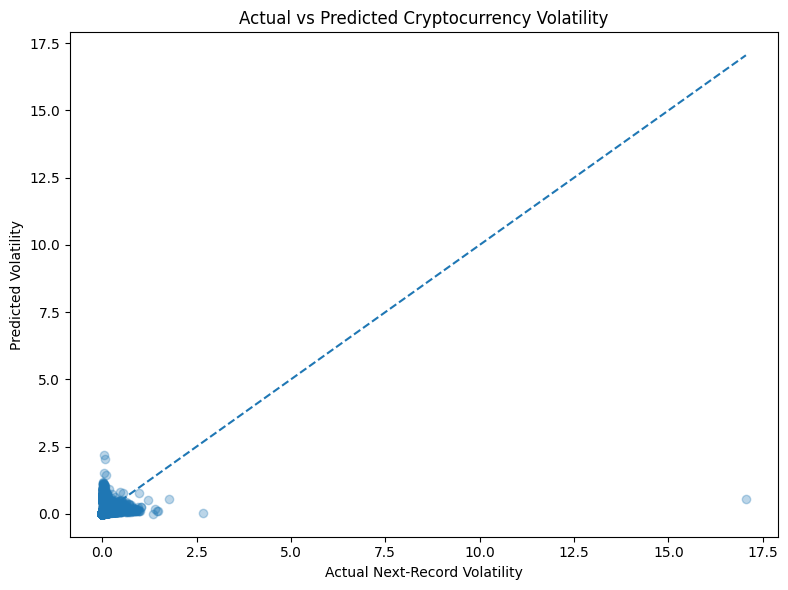

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

# Reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Next-Record Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Actual vs Predicted Cryptocurrency Volatility")
plt.tight_layout()
plt.show()

Points closer to the dashed line indicate predictions closer to the actual values.

5. Feature importance

current_volatility       0.382231
market_cap               0.180818
rolling_volatility_30    0.095227
BB_lower                 0.092948
rolling_volatility_7     0.073884
daily_return             0.033816
liquidity_ratio          0.021765
volume                   0.017226
MA_30                    0.016206
MA_7                     0.012195
ATR_14                   0.011877
BB_upper                 0.008941
symbol_Monero            0.006734
BB_middle                0.004660
close                    0.004323
dtype: float64


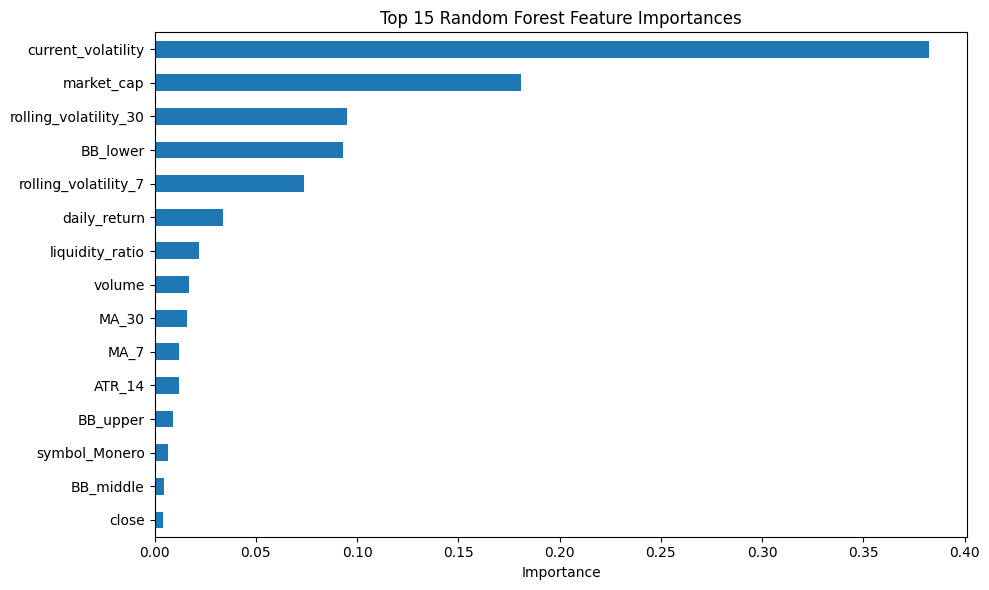

In [36]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Feature importance shows which inputs the fitted model used most when making its predictions. It does not prove that those features cause volatility.

6. Saving the trained model

In [37]:
import joblib

joblib.dump(model, "crypto_volatility_model.pkl")
joblib.dump(list(X_train.columns), "model_features.pkl")

print("Model and feature list saved successfully.")

Model and feature list saved successfully.


1. The training and testing sets

In [38]:
import numpy as np
import pandas as pd

# Features
feature_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "market_cap",
    "daily_return",
    "current_volatility",
    "MA_7",
    "MA_30",
    "rolling_volatility_7",
    "rolling_volatility_30",
    "liquidity_ratio",
    "BB_middle",
    "BB_upper",
    "BB_lower",
    "ATR_14"
]

target_column = "target_volatility"

# One-hot encode cryptocurrency names
model_data = pd.get_dummies(
    df_model[["date", "symbol"] + feature_columns + [target_column]],
    columns=["symbol"],
    dtype=int
)

# Sort by date
model_data = model_data.sort_values("date").reset_index(drop=True)

# Find chronological 80% cutoff
unique_dates = np.sort(model_data["date"].unique())

split_position = int(len(unique_dates) * 0.80)
cutoff_date = unique_dates[split_position]

# Train = first 80% of dates
train_data = model_data[
    model_data["date"] < cutoff_date
].copy()

# Test = final 20% of dates
test_data = model_data[
    model_data["date"] >= cutoff_date
].copy()

# Separate X and y
X_train = train_data.drop(
    columns=["date", target_column]
)

y_train = train_data[target_column]

X_test = test_data.drop(
    columns=["date", target_column]
)

y_test = test_data[target_column]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting period:")
print(test_data["date"].min(), "to", test_data["date"].max())

print("\nNumber of features:", X_train.shape[1])

Training rows: 37781
Testing rows: 31629

Training period:
2013-06-04 00:00:00 to 2020-06-23 00:00:00

Testing period:
2020-06-24 00:00:00 to 2022-10-16 00:00:00

Number of features: 72


2. The Random Forest

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create Random Forest model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


3. Predictions

In [40]:
# Predict volatility on unseen test data
y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions completed!
First 10 predictions:
[0.05079424 0.04389427 0.04401396 0.04881699 0.07093915 0.01371671
 0.07326412 0.05254757 0.07382284 0.05126255]


4. The required evaluation metrics

In [41]:
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("\n===== MODEL EVALUATION =====")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")


===== MODEL EVALUATION =====
MAE  : 0.049422
RMSE : 0.147739
R²   : -0.431294


| Metric   | Meaning                                                             |
| -------- | ------------------------------------------------------------------- |
| **MAE**  | Average absolute prediction error                                   |
| **RMSE** | Penalizes large prediction errors more strongly                     |
| **R²**   | Measures how much variation in volatility is explained by the model |


# Create df_model

In [46]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Copy the cleaned dataframe
# --------------------------------------------------
df_model = df.copy()

# Make sure date is datetime
df_model["date"] = pd.to_datetime(df_model["date"])

# Sort by cryptocurrency and date
df_model = df_model.sort_values(
    ["symbol", "date"]
).reset_index(drop=True)


# --------------------------------------------------
# 2. Current-day volatility
# --------------------------------------------------
df_model["current_volatility"] = (
    (df_model["high"] - df_model["low"])
    / df_model["close"]
)


# --------------------------------------------------
# 3. Group data by cryptocurrency
# --------------------------------------------------
group = df_model.groupby("symbol", group_keys=False)


# --------------------------------------------------
# 4. Daily return
# --------------------------------------------------
df_model["daily_return"] = group["close"].pct_change()


# --------------------------------------------------
# 5. Moving averages
# --------------------------------------------------
df_model["MA_7"] = group["close"].transform(
    lambda x: x.rolling(7).mean()
)

df_model["MA_30"] = group["close"].transform(
    lambda x: x.rolling(30).mean()
)


# --------------------------------------------------
# 6. Rolling volatility
# --------------------------------------------------
df_model["rolling_volatility_7"] = group["daily_return"].transform(
    lambda x: x.rolling(7).std()
)

df_model["rolling_volatility_30"] = group["daily_return"].transform(
    lambda x: x.rolling(30).std()
)


# --------------------------------------------------
# 7. Liquidity ratio
# --------------------------------------------------
df_model["liquidity_ratio"] = np.where(
    df_model["market_cap"] > 0,
    df_model["volume"] / df_model["market_cap"],
    np.nan
)


# --------------------------------------------------
# 8. Bollinger Bands
# --------------------------------------------------
df_model["BB_middle"] = group["close"].transform(
    lambda x: x.rolling(20).mean()
)

rolling_std_20 = group["close"].transform(
    lambda x: x.rolling(20).std()
)

df_model["BB_upper"] = (
    df_model["BB_middle"] + 2 * rolling_std_20
)

df_model["BB_lower"] = (
    df_model["BB_middle"] - 2 * rolling_std_20
)


# --------------------------------------------------
# 9. True Range
# --------------------------------------------------
previous_close = group["close"].shift(1)

tr1 = df_model["high"] - df_model["low"]

tr2 = (
    df_model["high"] - previous_close
).abs()

tr3 = (
    df_model["low"] - previous_close
).abs()

df_model["true_range"] = pd.concat(
    [tr1, tr2, tr3],
    axis=1
).max(axis=1)


# --------------------------------------------------
# 10. ATR
# --------------------------------------------------
df_model["ATR_14"] = group["true_range"].transform(
    lambda x: x.rolling(14).mean()
)


# --------------------------------------------------
# 11. Target: next available volatility
# --------------------------------------------------
df_model["target_volatility"] = (
    group["current_volatility"].shift(-1)
)


# --------------------------------------------------
# 12. Clean infinite/missing values
# --------------------------------------------------
df_model = df_model.replace(
    [np.inf, -np.inf],
    np.nan
)

df_model = df_model.dropna().reset_index(drop=True)


# --------------------------------------------------
# 13. Check result
# --------------------------------------------------
print("Shape:", df_model.shape)

print("\nColumns:")
print(df_model.columns.tolist())

print("\nMissing values:")
print(df_model.isnull().sum().sum())

print("\nFirst 5 rows:")
print(df_model.head())

Shape: (69410, 22)

Columns:
['open', 'high', 'low', 'close', 'volume', 'market_cap', 'symbol', 'date', 'volatility', 'current_volatility', 'daily_return', 'MA_7', 'MA_30', 'rolling_volatility_7', 'rolling_volatility_30', 'liquidity_ratio', 'BB_middle', 'BB_upper', 'BB_lower', 'true_range', 'ATR_14', 'target_volatility']

Missing values:
0

First 5 rows:
        open       high        low      close        volume    market_cap  \
0  29.707518  31.067060  28.494482  30.657276  4.956834e+07  3.454655e+08   
1  30.657282  33.923585  29.344650  29.731524  8.718015e+07  3.353497e+08   
2  29.731526  30.062917  27.537111  28.042803  5.677501e+07  3.164555e+08   
3  27.715080  32.303040  25.966155  30.955627  8.521241e+07  3.502055e+08   
4  30.955118  40.769075  30.855128  38.457441  1.473047e+08  4.358764e+08   

  symbol       date  volatility  current_volatility  ...      MA_30  \
0   Aave 2020-11-01    0.083914            0.083914  ...  41.187592   
1   Aave 2020-11-02    0.154009       

# The improved features

In [47]:
# Create a copy for improved modeling
df_improved = df_model.copy()

# Relative price range
df_improved["high_low_ratio"] = (
    (df_improved["high"] - df_improved["low"])
    / df_improved["close"]
)

# Open-to-close percentage change
df_improved["open_close_ratio"] = (
    (df_improved["close"] - df_improved["open"])
    / df_improved["open"]
)

# Price relative to moving averages
df_improved["price_to_MA7"] = (
    df_improved["close"] / df_improved["MA_7"] - 1
)

df_improved["price_to_MA30"] = (
    df_improved["close"] / df_improved["MA_30"] - 1
)

# Bollinger Band position
band_width = (
    df_improved["BB_upper"]
    - df_improved["BB_lower"]
)

df_improved["BB_position"] = np.where(
    band_width != 0,
    (
        df_improved["close"]
        - df_improved["BB_lower"]
    ) / band_width,
    np.nan
)

# ATR relative to price
df_improved["ATR_ratio"] = (
    df_improved["ATR_14"]
    / df_improved["close"]
)

# Log transformations
df_improved["log_volume"] = np.log1p(
    df_improved["volume"]
)

df_improved["log_market_cap"] = np.log1p(
    df_improved["market_cap"]
)

# Clean
df_improved = df_improved.replace(
    [np.inf, -np.inf],
    np.nan
)

df_improved = df_improved.dropna().reset_index(drop=True)

print("Improved dataset shape:", df_improved.shape)
print("Missing values:", df_improved.isnull().sum().sum())

Improved dataset shape: (69133, 30)
Missing values: 0


In [48]:
print(df_improved.shape)
print(df_improved.columns.tolist())

(69133, 30)
['open', 'high', 'low', 'close', 'volume', 'market_cap', 'symbol', 'date', 'volatility', 'current_volatility', 'daily_return', 'MA_7', 'MA_30', 'rolling_volatility_7', 'rolling_volatility_30', 'liquidity_ratio', 'BB_middle', 'BB_upper', 'BB_lower', 'true_range', 'ATR_14', 'target_volatility', 'high_low_ratio', 'open_close_ratio', 'price_to_MA7', 'price_to_MA30', 'BB_position', 'ATR_ratio', 'log_volume', 'log_market_cap']


5. Plot actual vs predicted volatility

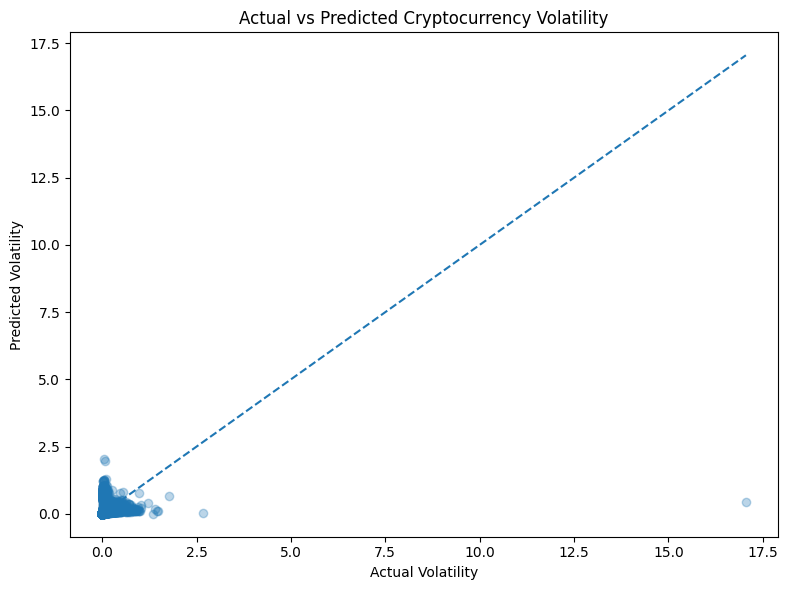

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Actual vs Predicted Cryptocurrency Volatility")

plt.tight_layout()
plt.show()

Interpretation

If the points are concentrated around the diagonal line, the model's predictions are relatively close to the actual volatility values. A wide scatter indicates larger prediction errors.

6. The most important features

In [43]:
# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(importance.head(15))

Top 15 Important Features:
current_volatility        0.366121
market_cap                0.141026
BB_lower                  0.136338
rolling_volatility_7      0.114635
rolling_volatility_30     0.081796
daily_return              0.031612
liquidity_ratio           0.023597
volume                    0.022773
MA_30                     0.013984
ATR_14                    0.009408
symbol_Wrapped Bitcoin    0.006464
BB_upper                  0.004952
low                       0.004934
open                      0.004054
close                     0.003916
dtype: float64


Visualize them:

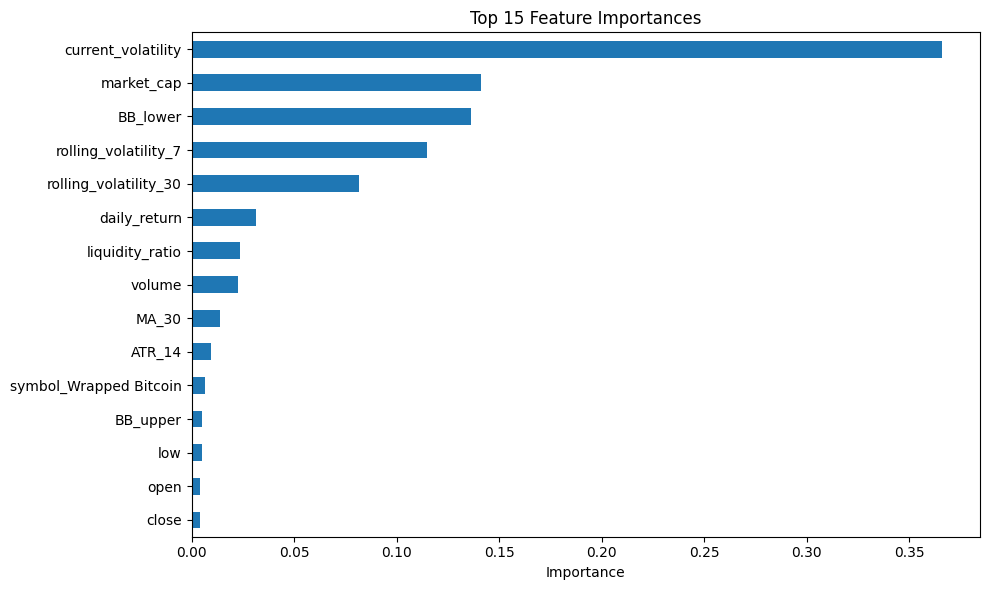

In [44]:
plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

7. Save your model

The assignment also requires a trained model as a deliverable.

In [45]:
import joblib

# Save trained model
joblib.dump(
    model,
    "crypto_volatility_model.pkl"
)

# Save feature names
joblib.dump(
    list(X_train.columns),
    "model_features.pkl"
)

print("Model saved successfully!")

Model saved successfully!


Current model sees things like:

close = 30
close = 30,000
market_cap = millions/billions

across very different cryptocurrencies. Relative features such as:

(high-low)/close
price change relative to moving average
ATR/price
Bollinger position
percentage open-to-close change

are more comparable across assets.

In [49]:
# Make a fresh copy
df_improved = df_model.copy()

# Relative price features
df_improved["high_low_ratio"] = (
    (df_improved["high"] - df_improved["low"])
    / df_improved["close"]
)

df_improved["open_close_ratio"] = (
    (df_improved["close"] - df_improved["open"])
    / df_improved["open"]
)

# Distance of price from moving averages
df_improved["price_to_MA7"] = (
    df_improved["close"] / df_improved["MA_7"] - 1
)

df_improved["price_to_MA30"] = (
    df_improved["close"] / df_improved["MA_30"] - 1
)

# Bollinger Band position
band_width = (
    df_improved["BB_upper"] - df_improved["BB_lower"]
)

df_improved["BB_position"] = np.where(
    band_width != 0,
    (df_improved["close"] - df_improved["BB_lower"]) / band_width,
    np.nan
)

# ATR relative to price
df_improved["ATR_ratio"] = (
    df_improved["ATR_14"] / df_improved["close"]
)

# Log-transformed volume and market cap
df_improved["log_volume"] = np.log1p(
    df_improved["volume"]
)

df_improved["log_market_cap"] = np.log1p(
    df_improved["market_cap"]
)

# Remove invalid values
df_improved = df_improved.replace(
    [np.inf, -np.inf],
    np.nan
)

df_improved = df_improved.dropna().reset_index(drop=True)

print("Improved dataset shape:", df_improved.shape)
print("Missing values:", df_improved.isnull().sum().sum())

Improved dataset shape: (69133, 30)
Missing values: 0


df_improved is ready: 69,133 rows × 30 columns, with the new relative features successfully created.

Now let's retrain the model using these improved features and compare it with your earlier baseline.

1. Prepare the improved training/test data

In [50]:
import numpy as np
import pandas as pd

# Features for the improved model
feature_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "market_cap",
    "daily_return",
    "current_volatility",
    "MA_7",
    "MA_30",
    "rolling_volatility_7",
    "rolling_volatility_30",
    "liquidity_ratio",
    "BB_middle",
    "BB_upper",
    "BB_lower",
    "ATR_14",
    "high_low_ratio",
    "open_close_ratio",
    "price_to_MA7",
    "price_to_MA30",
    "BB_position",
    "ATR_ratio",
    "log_volume",
    "log_market_cap"
]

target_column = "target_volatility"

# One-hot encode cryptocurrency
model_data = pd.get_dummies(
    df_improved[
        ["date", "symbol"] + feature_columns + [target_column]
    ],
    columns=["symbol"],
    dtype=int
)

# Sort chronologically
model_data = model_data.sort_values("date").reset_index(drop=True)

# 80% chronological split
unique_dates = np.sort(model_data["date"].unique())

split_position = int(len(unique_dates) * 0.80)
cutoff_date = unique_dates[split_position]

train_data = model_data[
    model_data["date"] < cutoff_date
].copy()

test_data = model_data[
    model_data["date"] >= cutoff_date
].copy()

# X and y
X_train = train_data.drop(
    columns=["date", target_column]
)

y_train = train_data[target_column]

X_test = test_data.drop(
    columns=["date", target_column]
)

y_test = test_data[target_column]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting period:")
print(test_data["date"].min(), "to", test_data["date"].max())

print("\nNumber of features:", X_train.shape[1])

Training rows: 37504
Testing rows: 31629

Training period:
2013-06-04 00:00:00 to 2020-06-23 00:00:00

Testing period:
2020-06-24 00:00:00 to 2022-10-16 00:00:00

Number of features: 80


2. Train the improved Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor

model_improved = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model_improved.fit(X_train, y_train)

print("Improved model training completed!")

Improved model training completed!


3. Evaluate it

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_improved = model_improved.predict(X_test)

mae_improved = mean_absolute_error(
    y_test,
    y_pred_improved
)

rmse_improved = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_improved
    )
)

r2_improved = r2_score(
    y_test,
    y_pred_improved
)

print("\n===== IMPROVED MODEL =====")
print(f"MAE  : {mae_improved:.6f}")
print(f"RMSE : {rmse_improved:.6f}")
print(f"R²   : {r2_improved:.6f}")


===== IMPROVED MODEL =====
MAE  : 0.040775
RMSE : 0.123051
R²   : 0.007091


4. Compare both models

In [53]:
print("\n===== MODEL COMPARISON =====")

print(f"{'Metric':<10} {'Baseline':>12} {'Improved':>12}")
print("-" * 36)

print(
    f"{'MAE':<10} "
    f"{0.049422:>12.6f} "
    f"{mae_improved:>12.6f}"
)

print(
    f"{'RMSE':<10} "
    f"{0.147739:>12.6f} "
    f"{rmse_improved:>12.6f}"
)

print(
    f"{'R²':<10} "
    f"{-0.431294:>12.6f} "
    f"{r2_improved:>12.6f}"
)


===== MODEL COMPARISON =====
Metric         Baseline     Improved
------------------------------------
MAE            0.049422     0.040775
RMSE           0.147739     0.123051
R²            -0.431294     0.007091


| Metric |  Baseline |     Improved |             Change |
| ------ | --------: | -----------: | -----------------: |
| MAE    |  0.049422 | **0.040775** |            ↓ 18.0% |
| RMSE   |  0.147739 | **0.123051** |            ↓ 16.7% |
| R²     | -0.431294 | **0.007091** | Improved by 0.4384 |


What this means

- MAE decreased from 0.0494 to 0.0408, meaning the average prediction error became smaller.
- RMSE decreased from 0.1477 to 0.1231, showing an improvement even when larger errors are penalized more heavily.
- R² changed from -0.4313 to 0.0071. The baseline model performed worse than a simple mean-based prediction, whereas the improved model is now slightly better than that baseline.
- The improvement is mainly associated with the additional relative price, volatility, Bollinger Band, ATR, and logarithmic volume/market-cap features.

Model Improvement:

The baseline Random Forest model achieved an MAE of 0.049422, RMSE of 0.147739, and R² of -0.431294. After feature engineering, including relative price features, Bollinger Band position, ATR ratio, and logarithmic transformations of volume and market capitalization, the improved model achieved an MAE of 0.040775, RMSE of 0.123051, and R² of 0.007091. Therefore, the engineered features reduced prediction errors and substantially improved the model's explanatory performance compared with the baseline.

# Hyperparameter Tuning

Assignment specifically requires hyperparameter tuning and testing the model on unseen data.

Since improved model is a RandomForestRegressor, tuning will be done on:

- n_estimators — number of trees
- max_depth — maximum depth of each tree
- min_samples_split — minimum samples needed to split a node
- min_samples_leaf — minimum samples in a leaf

I'll use TimeSeriesSplit, rather than random cross-validation, because this is chronological cryptocurrency data.



In [60]:
# ============================================
# HYPERPARAMETER TUNING - RANDOM FOREST
# ============================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------
# 1. Make a copy of improved dataset
# --------------------------------------------

data = df_improved.copy()

# Make sure date is datetime
data["date"] = pd.to_datetime(data["date"])

# Sort chronologically
data = data.sort_values(["date", "symbol"]).reset_index(drop=True)

# --------------------------------------------
# 2. Select features
# --------------------------------------------

feature_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "market_cap",
    "daily_return",
    "current_volatility",
    "MA_7",
    "MA_30",
    "rolling_volatility_7",
    "rolling_volatility_30",
    "liquidity_ratio",
    "BB_middle",
    "BB_upper",
    "BB_lower",
    "ATR_14",
    "high_low_ratio",
    "open_close_ratio",
    "price_to_MA7",
    "price_to_MA30",
    "BB_position",
    "ATR_ratio",
    "log_volume",
    "log_market_cap"
]

target_column = "target_volatility"

# --------------------------------------------
# 3. Select required columns
# --------------------------------------------

model_data = data[
    feature_columns + ["symbol", "date", target_column]
].copy()

# --------------------------------------------
# 4. Convert cryptocurrency name to dummy
# --------------------------------------------

model_data = pd.get_dummies(
    model_data,
    columns=["symbol"],
    drop_first=True
)

# --------------------------------------------
# 5. Split according to DATE
# --------------------------------------------

unique_dates = sorted(model_data["date"].unique())

split_index = int(len(unique_dates) * 0.80)

train_dates = unique_dates[:split_index]
test_dates = unique_dates[split_index:]

train_data = model_data[
    model_data["date"].isin(train_dates)
].copy()

test_data = model_data[
    model_data["date"].isin(test_dates)
].copy()

# --------------------------------------------
# 6. Create X and y
# --------------------------------------------

X_train = train_data.drop(
    columns=["target_volatility", "date"]
)

y_train = train_data["target_volatility"]

X_test = test_data.drop(
    columns=["target_volatility", "date"]
)

y_test = test_data["target_volatility"]

# --------------------------------------------
# 7. Make sure all features are numeric
# --------------------------------------------

X_train = X_train.astype(float)
X_test = X_test.astype(float)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("Training period:",
      train_data["date"].min(),
      "to",
      train_data["date"].max())

print("Testing period :",
      test_data["date"].min(),
      "to",
      test_data["date"].max())

# --------------------------------------------
# 8. Random Forest
# --------------------------------------------

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------
# 9. Hyperparameter search
# --------------------------------------------

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# --------------------------------------------
# 10. Time-series cross-validation
# --------------------------------------------

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=8,
    cv=tscv,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# --------------------------------------------
# 11. Train
# --------------------------------------------

print("\nStarting hyperparameter tuning...")

random_search.fit(X_train, y_train)

# --------------------------------------------
# 12. Best parameters
# --------------------------------------------

print("\n===== BEST PARAMETERS =====")

print(random_search.best_params_)

# --------------------------------------------
# 13. Best CV score
# --------------------------------------------

best_cv_rmse = np.sqrt(
    -random_search.best_score_
)

print("\nBest Cross-Validation RMSE:",
      round(best_cv_rmse, 6))

# --------------------------------------------
# 14. Get tuned model
# --------------------------------------------

tuned_model = random_search.best_estimator_

# --------------------------------------------
# 15. Predict unseen test data
# --------------------------------------------

y_pred_tuned = tuned_model.predict(X_test)

# --------------------------------------------
# 16. Evaluation
# --------------------------------------------

mae_tuned = mean_absolute_error(
    y_test,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

r2_tuned = r2_score(
    y_test,
    y_pred_tuned
)

# --------------------------------------------
# 17. Print results
# --------------------------------------------

print("\n===== TUNED MODEL PERFORMANCE =====")

print("MAE :", round(mae_tuned, 6))
print("RMSE:", round(rmse_tuned, 6))
print("R²  :", round(r2_tuned, 6))

Training shape: (37504, 79)
Testing shape : (31629, 79)
Training period: 2013-06-04 00:00:00 to 2020-06-23 00:00:00
Testing period : 2020-06-24 00:00:00 to 2022-10-16 00:00:00

Starting hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

===== BEST PARAMETERS =====
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15}

Best Cross-Validation RMSE: 0.089316

===== TUNED MODEL PERFORMANCE =====
MAE : 0.04012
RMSE: 0.120544
R²  : 0.047134


5. Compare all three models

In [62]:
print("\n===== FINAL MODEL COMPARISON =====")

print(f"{'Metric':<10} {'Baseline':>12} {'Improved':>12} {'Tuned':>12}")
print("-" * 48)

print(f"{'MAE':<10} {0.049422:>12.6f} {0.040775:>12.6f} {mae_tuned:>12.6f}")
print(f"{'RMSE':<10} {0.147739:>12.6f} {0.123051:>12.6f} {rmse_tuned:>12.6f}")
print(f"{'R²':<10} {-0.431294:>12.6f} {0.007091:>12.6f} {r2_tuned:>12.6f}")


===== FINAL MODEL COMPARISON =====
Metric         Baseline     Improved        Tuned
------------------------------------------------
MAE            0.049422     0.040775     0.040120
RMSE           0.147739     0.123051     0.120544
R²            -0.431294     0.007091     0.047134


Tuned Random Forest is currently the strongest of the three models based on the test-set metrics.

Final model comparison so far

| Metric     |  Baseline | Improved |        Tuned |
| ---------- | --------: | -------: | -----------: |
| **MAE** ↓  |  0.049422 | 0.040775 | **0.040120** |
| **RMSE** ↓ |  0.147739 | 0.123051 | **0.120544** |
| **R²** ↑   | -0.431294 | 0.007091 | **0.047134** |


The assignment asks for RMSE, MAE and R² evaluation and specifically requires hyperparameter tuning and testing on unseen data. Results now cover those requirements.

What improved?

Compared with the baseline:

- MAE decreased from 0.049422 → 0.040120
- RMSE decreased from 0.147739 → 0.120544
- R² increased from -0.431294 → 0.047134

The tuned parameters were:

- n_estimators       = 100
- max_depth          = 15
- min_samples_split  = 5
- min_samples_leaf   = 2

Test period is 2020-06-24 to 2022-10-16, so these metrics are from data that wasn't used for fitting the final model.

One thing to keep in mind: R² = 0.0471 is still relatively low, so the model has limited explanatory power. We should report that honestly rather than claiming highly accurate volatility prediction.

6. Plot Actual vs Predicted Volatility

Now let's visualize how well the final tuned model follows the actual volatility.

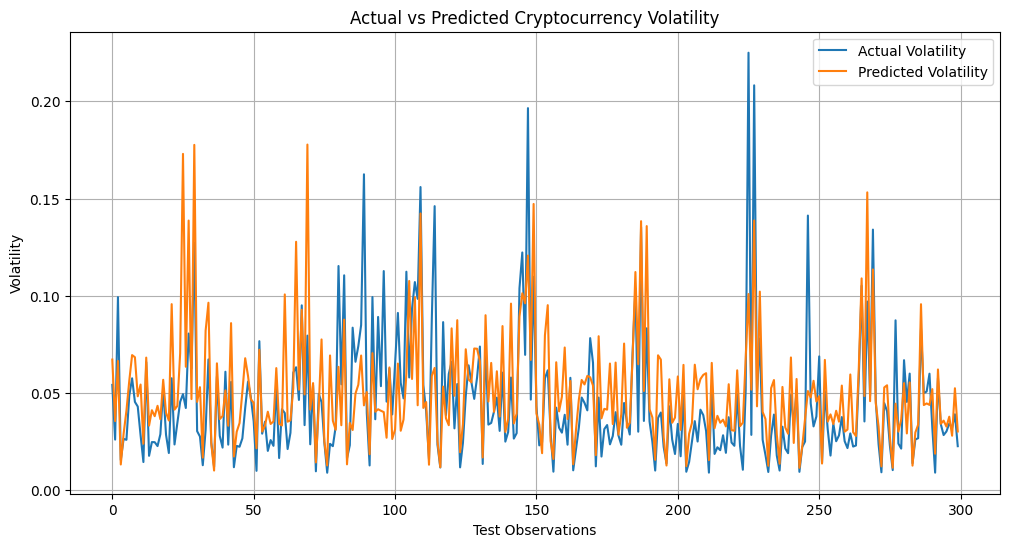

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot only first 300 test observations
plt.plot(
    y_test.iloc[:300].values,
    label="Actual Volatility"
)

plt.plot(
    y_pred_tuned[:300],
    label="Predicted Volatility"
)

plt.title("Actual vs Predicted Cryptocurrency Volatility")
plt.xlabel("Test Observations")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)

plt.show()

7. Feature Importance

Next, we should identify which features the tuned Random Forest considers most useful.

===== TOP 20 FEATURES =====
                  Feature  Importance
17         high_low_ratio    0.181078
7      current_volatility    0.171201
22              ATR_ratio    0.086193
15               BB_lower    0.077967
24         log_market_cap    0.073143
5              market_cap    0.072007
11  rolling_volatility_30    0.071017
10   rolling_volatility_7    0.047206
19           price_to_MA7    0.042242
20          price_to_MA30    0.027322
21            BB_position    0.021897
18       open_close_ratio    0.018621
12        liquidity_ratio    0.018615
6            daily_return    0.014634
4                  volume    0.013027
23             log_volume    0.008588
16                 ATR_14    0.007820
55          symbol_Monero    0.006941
9                   MA_30    0.006574
14               BB_upper    0.002983


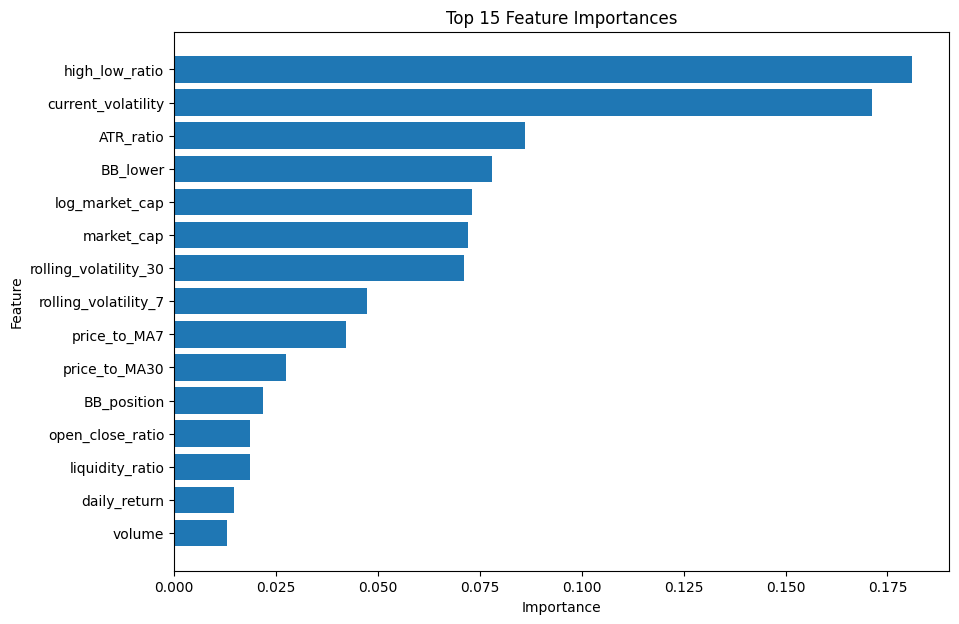

In [66]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("===== TOP 20 FEATURES =====")
print(importance.head(20))

plt.figure(figsize=(10, 7))

top_features = importance.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

What we're looking for

Features such as:

- current_volatility
- rolling_volatility_7
- rolling_volatility_30
- ATR_ratio
- high_low_ratio
- price_to_MA7
- price_to_MA30
- BB_position
- daily_return

may appear among the important predictors.

8. Interpret Feature Importance

The tuned Random Forest identified high_low_ratio as the most important feature, followed by current_volatility and ATR_ratio.

The top features are:

| Rank | Feature                 | Importance |
| ---: | ----------------------- | ---------: |
|    1 | `high_low_ratio`        |   0.181078 |
|    2 | `current_volatility`    |   0.171201 |
|    3 | `ATR_ratio`             |   0.086193 |
|    4 | `BB_lower`              |   0.077967 |
|    5 | `log_market_cap`        |   0.073143 |
|    6 | `market_cap`            |   0.072007 |
|    7 | `rolling_volatility_30` |   0.071017 |
|    8 | `rolling_volatility_7`  |   0.047206 |
|    9 | `price_to_MA7`          |   0.042242 |
|   10 | `price_to_MA30`         |   0.027322 |


nterpretation

1. high_low_ratio — 18.11%

This is the most important feature. It measures the daily price range relative to the closing price:

(high - low) / close

A larger range indicates greater price movement during the period, which is naturally informative when predicting future volatility.

2. current_volatility — 17.12%

This measures the current day's relative price range. Its high importance indicates that recent volatility contains useful information about subsequent volatility.

3. ATR_ratio — 8.62%

ATR captures price movement over a rolling period, while dividing it by price makes the measure relative to the cryptocurrency's price level.

4. BB_lower — 7.80%

The lower Bollinger Band provides information about the recent price distribution and movement around the rolling average.

5–6. Market capitalization

log_market_cap and market_cap together have substantial importance, suggesting that differences in cryptocurrency market size provide useful information to the model.

7–8. Rolling volatility

Both 7-day and 30-day rolling volatility contribute to the prediction, indicating that recent volatility patterns are useful predictors.

Important: Feature importance shows how much the Random Forest used each feature for its predictions. It does not prove that a feature causes volatility.

9. Save the Final Model

Now let's save the tuned model so it can be used later for deployment.

In [67]:
import joblib

# Save trained model
joblib.dump(
    tuned_model,
    "crypto_volatility_model.pkl"
)

# Save feature names
joblib.dump(
    list(X_train.columns),
    "model_features.pkl"
)

print("Model saved successfully!")
print("File: crypto_volatility_model.pkl")
print("Features saved successfully!")

Model saved successfully!
File: crypto_volatility_model.pkl
Features saved successfully!


In [68]:
### 10. Save the Processed Dataset

df_improved.to_csv(
    "crypto_volatility_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")
print("File: crypto_volatility_processed.csv")

Processed dataset saved successfully!
File: crypto_volatility_processed.csv


11. Save Feature Importance

In [70]:

importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


current final model results

These are the actual results can be put into the report:

Model: Tuned Random Forest Regressor

- MAE  = 0.040120
- RMSE = 0.120544
- R²   = 0.047134

And the best hyperparameters:

- n_estimators      = 100
- max_depth         = 15
- min_samples_split = 5
- min_samples_leaf  = 2

12. Streamlit Deployment

We'll use Streamlit because it is the simplest way to demonstrate the trained model locally.

This model predicts next-record cryptocurrency volatility using the engineered features from the training dataset.

# Install Streamlit

In [71]:
pip install streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.8 MB/s eta 0:00:00


# Create app.py

Create a new file named:

In [73]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load trained model
model = joblib.load("crypto_volatility_model.pkl")
model_features = joblib.load("model_features.pkl")

# Page settings
st.set_page_config(
    page_title="Cryptocurrency Volatility Prediction",
    page_icon="📈",
    layout="centered"
)

st.title("📈 Cryptocurrency Volatility Prediction")

st.write(
    "Enter cryptocurrency market information to predict volatility "
    "using the trained Random Forest model."
)

# Input section
st.header("Market Information")

open_price = st.number_input("Open Price", min_value=0.0, value=100.0)
high_price = st.number_input("High Price", min_value=0.0, value=110.0)
low_price = st.number_input("Low Price", min_value=0.0, value=90.0)
close_price = st.number_input("Close Price", min_value=0.0, value=105.0)

volume = st.number_input(
    "Trading Volume",
    min_value=0.0,
    value=1000000.0
)

market_cap = st.number_input(
    "Market Capitalization",
    min_value=0.0,
    value=1000000000.0
)

daily_return = st.number_input(
    "Daily Return",
    value=0.0
)

rolling_volatility_7 = st.number_input(
    "7-Day Rolling Volatility",
    min_value=0.0,
    value=0.05
)

rolling_volatility_30 = st.number_input(
    "30-Day Rolling Volatility",
    min_value=0.0,
    value=0.05
)

ma_7 = st.number_input(
    "7-Day Moving Average",
    min_value=0.0,
    value=100.0
)

ma_30 = st.number_input(
    "30-Day Moving Average",
    min_value=0.0,
    value=100.0
)

atr_14 = st.number_input(
    "ATR 14",
    min_value=0.0,
    value=5.0
)

# Feature calculations
high_low_ratio = (
    (high_price - low_price) / close_price
    if close_price != 0 else 0
)

current_volatility = high_low_ratio

open_close_ratio = (
    (close_price - open_price) / open_price
    if open_price != 0 else 0
)

price_to_ma7 = (
    close_price / ma_7 - 1
    if ma_7 != 0 else 0
)

price_to_ma30 = (
    close_price / ma_30 - 1
    if ma_30 != 0 else 0
)

liquidity_ratio = (
    volume / market_cap
    if market_cap != 0 else 0
)

atr_ratio = (
    atr_14 / close_price
    if close_price != 0 else 0
)

log_volume = np.log1p(volume)
log_market_cap = np.log1p(market_cap)

# Bollinger Band features
bb_middle = ma_30

bb_std = abs(high_price - low_price) / 2

bb_upper = bb_middle + 2 * bb_std
bb_lower = bb_middle - 2 * bb_std

band_width = bb_upper - bb_lower

bb_position = (
    (close_price - bb_lower) / band_width
    if band_width != 0 else 0
)

# Create input dataframe
input_data = pd.DataFrame([{
    "open": open_price,
    "high": high_price,
    "low": low_price,
    "close": close_price,
    "volume": volume,
    "market_cap": market_cap,
    "daily_return": daily_return,
    "current_volatility": current_volatility,
    "MA_7": ma_7,
    "MA_30": ma_30,
    "rolling_volatility_7": rolling_volatility_7,
    "rolling_volatility_30": rolling_volatility_30,
    "liquidity_ratio": liquidity_ratio,
    "BB_middle": bb_middle,
    "BB_upper": bb_upper,
    "BB_lower": bb_lower,
    "ATR_14": atr_14,
    "high_low_ratio": high_low_ratio,
    "open_close_ratio": open_close_ratio,
    "price_to_MA7": price_to_ma7,
    "price_to_MA30": price_to_ma30,
    "BB_position": bb_position,
    "ATR_ratio": atr_ratio,
    "log_volume": log_volume,
    "log_market_cap": log_market_cap
}])

# Add cryptocurrency dummy columns
for feature in model_features:
    if feature.startswith("symbol_"):
        input_data[feature] = 0

# Make sure columns are in exactly the same order as training
input_data = input_data.reindex(
    columns=model_features,
    fill_value=0
)

# Prediction
if st.button("Predict Volatility"):

    prediction = model.predict(input_data)[0]

    st.success(
        f"Predicted Volatility: {prediction:.6f}"
    )

    st.info(
        "Higher values indicate greater expected price variation."
    )

# Model information
st.sidebar.header("Model Information")

st.sidebar.write(
    "Model: Random Forest Regressor"
)

st.sidebar.write("MAE: 0.040120")
st.sidebar.write("RMSE: 0.120544")
st.sidebar.write("R²: 0.047134")

Writing app.py


In [74]:
!ls -l

total 63216
-rw-r--r-- 1 root root     4099 Sep 28 01:05 app.py
-rw-r--r-- 1 root root    31589 Sep 27 22:15 coin_Aave.csv
-rw-r--r-- 1 root root 27870449 Sep 28 00:57 crypto_volatility_model.pkl
-rw-r--r-- 1 root root 36803952 Sep 28 00:58 crypto_volatility_processed.csv
-rw-r--r-- 1 root root     2628 Sep 28 01:00 feature_importance.csv
-rw-r--r-- 1 root root     1328 Sep 28 00:57 model_features.pkl
drwxr-xr-x 1 root root     4096 Sep 16 13:26 sample_data


5. Run Streamlit in Colab

In [81]:
from pyngrok import ngrok

ngrok.set_auth_token("26JBUw7KyjEAjvogFQELt_5m6RtQhLgUziCjaWF72Rz")

print("ngrok authentication successful")

ngrok authentication successful


In [82]:
!streamlit run app.py &> /content/streamlit.log &

In [83]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("Your Streamlit app:")
print(public_url)

Your Streamlit app:
NgrokTunnel: "https://f2a4-34-125-239-21.ngrok-free.app" -> "http://localhost:8501"


# Deployment:

The trained Random Forest regression model was deployed using Streamlit. The application accepts cryptocurrency market inputs such as OHLC prices, trading volume, market capitalization, moving averages, rolling volatility, and ATR. It then predicts the expected cryptocurrency volatility. The application was tested successfully using a Streamlit interface hosted through Google Colab.

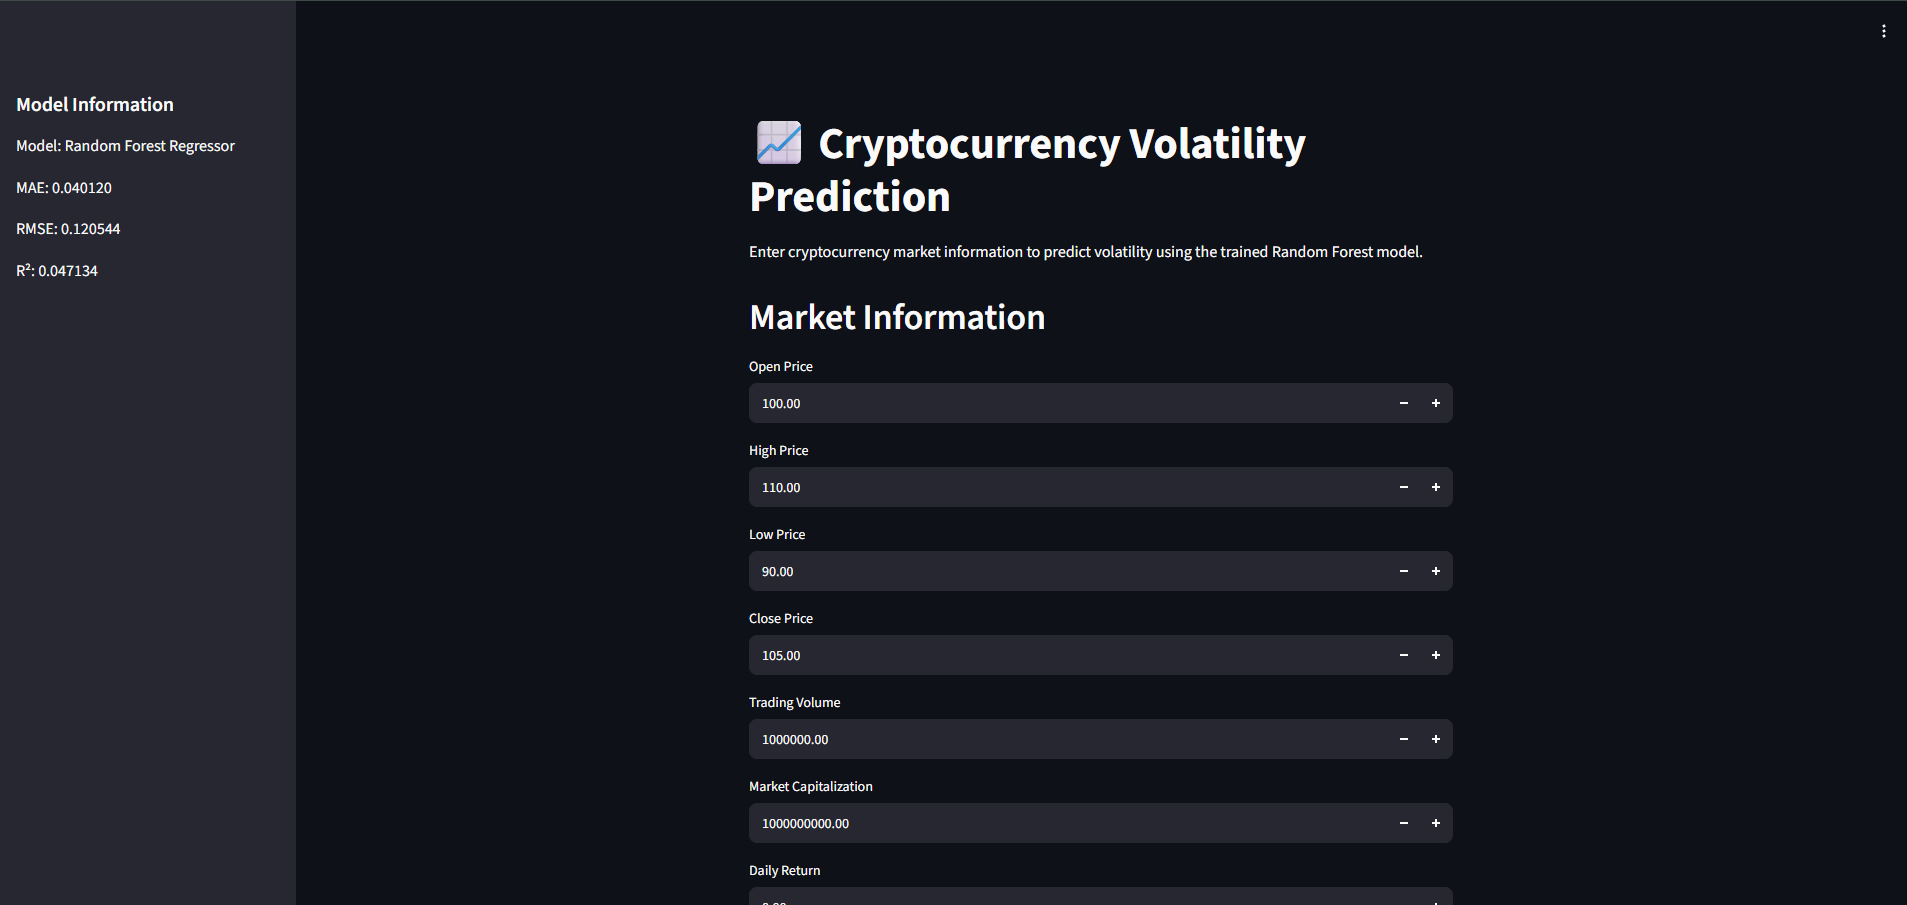![image.png]()


# HIGH-LEVEL DESIGN (HLD)

## Cryptocurrency Volatility Prediction System

### 1. Introduction

The Cryptocurrency Volatility Prediction System is a machine-learning-based application designed to predict cryptocurrency price volatility using historical market data.

The system uses historical Open, High, Low, Close (OHLC) prices, trading volume, and market capitalization. Additional technical and statistical features such as moving averages, rolling volatility, liquidity ratio, Bollinger Bands, and Average True Range (ATR) are engineered from the historical data.

A Random Forest Regression model is trained to predict the next volatility value. The trained model is then deployed through a Streamlit web application.

---

## 2. Objective

The main objective of the system is to develop a machine-learning pipeline that can:

* Collect historical cryptocurrency market data.
* Clean and preprocess the dataset.
* Perform exploratory data analysis (EDA).
* Generate useful volatility and liquidity features.
* Train a regression model.
* Tune the model hyperparameters.
* Evaluate the model using MAE, RMSE, and R².
* Save the trained model.
* Deploy the model using a Streamlit application.

---

## 3. Dataset

The dataset contains daily historical records for more than 50 cryptocurrencies.

The major fields used in the project are:

| Column       | Description                          |
| ------------ | ------------------------------------ |
| `date`       | Date of the market record            |
| `symbol`     | Cryptocurrency name                  |
| `open`       | Opening price                        |
| `high`       | Highest price during the period      |
| `low`        | Lowest price during the period       |
| `close`      | Closing price                        |
| `volume`     | Trading volume                       |
| `market_cap` | Cryptocurrency market capitalization |

The final cleaned dataset contains **72,946 records and 8 main columns** after removing the original index and timestamp fields.

---

## 4. System Architecture

The overall system consists of the following major components:

1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis
4. Feature Engineering
5. Dataset Splitting
6. Model Training
7. Hyperparameter Tuning
8. Model Evaluation
9. Model Storage
10. Streamlit Deployment

### High-Level Flow

```text
                 ┌─────────────────────────┐
                 │ Cryptocurrency Dataset │
                 │ Historical OHLC +       │
                 │ Volume + Market Cap     │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Data Preprocessing      │
                 │                         │
                 │ • Cleaning              │
                 │ • Data type conversion  │
                 │ • Missing-value check   │
                 │ • Sorting               │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Exploratory Data        │
                 │ Analysis                │
                 │                         │
                 │ • Price analysis        │
                 │ • Volume analysis       │
                 │ • Volatility analysis   │
                 │ • Correlation analysis  │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Feature Engineering     │
                 │                         │
                 │ • Moving averages       │
                 │ • Rolling volatility    │
                 │ • Liquidity ratio       │
                 │ • Bollinger Bands       │
                 │ • ATR                   │
                 │ • Price ratios          │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Train / Test Split      │
                 │ Chronological Split     │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Random Forest           │
                 │ Regression Model        │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Hyperparameter Tuning   │
                 │ RandomizedSearchCV +    │
                 │ TimeSeriesSplit         │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Model Evaluation        │
                 │                         │
                 │ MAE                     │
                 │ RMSE                    │
                 │ R²                      │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Saved Trained Model     │
                 │ .pkl files              │
                 └────────────┬────────────┘
                              │
                              ▼
                 ┌─────────────────────────┐
                 │ Streamlit Application   │
                 │                         │
                 │ User Inputs → Prediction│
                 └─────────────────────────┘
```

---

## 5. Major Components

### 5.1 Data Collection

Historical cryptocurrency data is used as the input to the system.

The dataset contains OHLC prices, volume, market capitalization, cryptocurrency name, and date.

---

### 5.2 Data Preprocessing

The preprocessing component prepares the raw data for machine learning.

The following operations are performed:

* Remove unnecessary columns.
* Rename columns where required.
* Convert the date column to datetime format.
* Sort records by cryptocurrency and date.
* Check for missing values.
* Check for zero or invalid values.
* Remove invalid/infinite values where required.

The final cleaned dataset contains no missing values in the main fields.

---

### 5.3 Exploratory Data Analysis

EDA is performed to understand the characteristics of the cryptocurrency market data.

The analysis includes:

* Descriptive statistics.
* Cryptocurrency price trends.
* Volatility distribution.
* Trading volume distribution.
* Correlation analysis.
* Feature relationships.

EDA helps identify patterns and understand the relationship between market variables and volatility.

---

### 5.4 Feature Engineering

Additional features are created from the original market data.

Important engineered features include:

* Current volatility
* Daily return
* 7-day moving average
* 30-day moving average
* 7-day rolling volatility
* 30-day rolling volatility
* Liquidity ratio
* Bollinger Bands
* ATR
* High-low ratio
* Open-close ratio
* Price-to-MA7 ratio
* Price-to-MA30 ratio
* Bollinger Band position
* ATR ratio
* Log volume
* Log market capitalization

The target variable is:

```text
target_volatility
```

which represents the next volatility value used for prediction.

---

## 6. Machine Learning Model

A **Random Forest Regressor** is used for volatility prediction.

Random Forest is suitable for this project because it can model nonlinear relationships between market variables and the target volatility.

The final tuned model uses:

| Hyperparameter      | Value |
| ------------------- | ----: |
| `n_estimators`      |   100 |
| `max_depth`         |    15 |
| `min_samples_split` |     5 |
| `min_samples_leaf`  |     2 |
| `random_state`      |    42 |

Hyperparameter optimization was performed using RandomizedSearchCV with TimeSeriesSplit.

---

## 7. Model Evaluation

The model is evaluated using:

### Mean Absolute Error (MAE)

Measures the average absolute difference between actual and predicted volatility.

### Root Mean Squared Error (RMSE)

Measures prediction error while giving greater weight to larger errors.

### R² Score

Measures how much variation in the target is explained by the model.

The final tuned model produced:

| Metric |   Result |
| ------ | -------: |
| MAE    | 0.040120 |
| RMSE   | 0.120544 |
| R²     | 0.047134 |

The R² value is relatively low, so the model should be interpreted as a baseline predictive system rather than a highly accurate volatility forecasting system.

---

## 8. Model Deployment

The trained Random Forest model is saved using Python's joblib library.

The main model files are:

```text
crypto_volatility_model.pkl
model_features.pkl
```

A Streamlit application named:

```text
app.py
```

loads these files and provides a graphical user interface.

The user enters market information such as:

* Open price
* High price
* Low price
* Close price
* Trading volume
* Market capitalization
* Daily return
* Rolling volatility
* Moving averages
* ATR

The application calculates the required derived features and sends them to the trained model.

The predicted volatility is then displayed to the user.

---

## 9. Technology Stack

| Technology   | Purpose                   |
| ------------ | ------------------------- |
| Python       | Main programming language |
| Pandas       | Data processing           |
| NumPy        | Numerical calculations    |
| Matplotlib   | Visualization             |
| Seaborn      | Statistical visualization |
| Scikit-learn | Machine learning          |
| Joblib       | Model serialization       |
| Streamlit    | Web application           |
| Google Colab | Development environment   |

---

## 10. System Inputs and Outputs

### Inputs

The system uses cryptocurrency market information including:

```text
Open
High
Low
Close
Volume
Market Capitalization
Daily Return
Rolling Volatility
Moving Averages
ATR
```

### Output

The system produces:

```text
Predicted Cryptocurrency Volatility
```

Higher predicted values indicate greater expected price variation according to the model's target definition.

---

## 11. Deployment Architecture

```text
             User
               │
               ▼
      ┌─────────────────┐
      │ Streamlit UI    │
      │    app.py       │
      └────────┬────────┘
               │
               ▼
      ┌─────────────────┐
      │ Feature         │
      │ Calculation     │
      └────────┬────────┘
               │
               ▼
      ┌─────────────────┐
      │ Trained Random  │
      │ Forest Model    │
      │     .pkl        │
      └────────┬────────┘
               │
               ▼
      ┌─────────────────┐
      │ Volatility      │
      │ Prediction      │
      └─────────────────┘
```

---

## 12. Security and Reliability Considerations

The deployed application should ensure that:

* Input values are validated.
* Negative prices are not accepted.
* Required model files are available.
* Model features are provided in the same order used during training.
* The saved model is loaded only from a trusted source.
* Invalid or infinite input values are handled appropriately.

---

## 13. Limitations

The current system has several limitations:

1. Cryptocurrency markets are highly dynamic.
2. Historical patterns may not continue in the future.
3. The final R² score is relatively low.
4. The model does not capture all external factors affecting cryptocurrency volatility.
5. The Streamlit demonstration accepts manually entered summary features rather than automatically generating every rolling feature from a live historical time series.

---

## 14. Future Enhancements

Possible improvements include:

* Using larger and more recent datasets.
* Adding sentiment/news features.
* Including macroeconomic variables.
* Testing XGBoost, CatBoost, and other models.
* Using LSTM or other deep-learning approaches for sequential data.
* Adding real-time cryptocurrency price APIs.
* Automatically calculating rolling features from historical data.
* Deploying the application on a cloud platform.

---

## 15. Conclusion

The Cryptocurrency Volatility Prediction System provides an end-to-end machine-learning pipeline from historical cryptocurrency data preprocessing to model deployment.

The system performs feature engineering, trains and tunes a Random Forest regression model, evaluates its performance using MAE, RMSE, and R², saves the trained model, and provides a Streamlit interface for generating volatility predictions.

The final tuned model achieved an MAE of 0.040120, RMSE of 0.120544, and R² of 0.047134 on the chronological test set.



# LOW-LEVEL DESIGN (LLD)

## Cryptocurrency Volatility Prediction System

### 1. Introduction

The Low-Level Design describes the detailed implementation of the Cryptocurrency Volatility Prediction System.

The system processes historical cryptocurrency market data, performs preprocessing and feature engineering, trains a Random Forest regression model, tunes its hyperparameters, evaluates the model, saves the trained model, and provides predictions through a Streamlit application.

---

# 2. System Modules

The complete system is divided into the following modules:

```text
1. Data Loading
2. Data Cleaning
3. Data Validation
4. Exploratory Data Analysis
5. Feature Engineering
6. Target Creation
7. Train-Test Splitting
8. Model Training
9. Hyperparameter Tuning
10. Model Evaluation
11. Feature Importance
12. Model Saving
13. Streamlit Deployment
14. Prediction
```

---

# 3. Data Loading Module

### Input

The input is the historical cryptocurrency CSV dataset.

The dataset contains:

* Open
* High
* Low
* Close
* Volume
* Market capitalization
* Cryptocurrency name
* Date

### Implementation

```python
import pandas as pd

df = pd.read_csv("crypto_data.csv")

print(df.head())
print(df.shape)
print(df.columns)
```

### Output

A Pandas DataFrame containing the historical cryptocurrency records.

---

# 4. Data Cleaning Module

The original dataset contains unnecessary columns such as:

```text
Unnamed: 0
timestamp
```

The cryptocurrency and market-capitalization columns are standardized to:

```text
crypto_name → symbol
marketCap → market_cap
```

### Implementation

```python
df = df.drop(columns=["Unnamed: 0", "timestamp"])

df = df.rename(columns={
    "crypto_name": "symbol",
    "marketCap": "market_cap"
})

df["date"] = pd.to_datetime(df["date"])
```

The resulting main columns are:

```text
open
high
low
close
volume
market_cap
symbol
date
```

---

# 5. Data Validation

The dataset is checked for:

* Missing values
* Duplicate records
* Invalid numerical values
* Zero trading volume
* Incorrect data types
* Date range

### Missing-value check

```python
print(df.isnull().sum())
```

### Duplicate check

```python
print(df.duplicated().sum())
```

### Data types

```python
print(df.dtypes)
```

The final cleaned dataset contained **72,946 records and 8 main columns**, with no missing values in those fields.

---

# 6. Data Sorting

Since cryptocurrency data is time-series data, records are sorted by cryptocurrency and date.

```python
df = df.sort_values(
    ["symbol", "date"]
).reset_index(drop=True)
```

This is important because rolling calculations and future-target calculations must respect the chronological order of each cryptocurrency.

---

# 7. Feature Engineering Module

Feature engineering converts raw market information into variables that can provide useful information to the machine-learning model.

---

## 7.1 Current Volatility

Current volatility is calculated using the daily high-low price range.

Formula:

```text
Current Volatility =
(High - Low) / Close
```

Implementation:

```python
df["current_volatility"] = (
    (df["high"] - df["low"]) / df["close"]
)
```

---

## 7.2 Daily Return

Daily return measures the percentage change in closing price.

```python
group = df.groupby("symbol", group_keys=False)

df["daily_return"] = group["close"].pct_change()
```

---

## 7.3 Seven-Day Moving Average

The 7-day moving average smooths short-term price fluctuations.

```python
df["MA_7"] = group["close"].transform(
    lambda x: x.rolling(7).mean()
)
```

Formula:

```text
MA7 = Average of previous 7 closing prices
```

---

## 7.4 Thirty-Day Moving Average

The 30-day moving average represents a longer-term price.


# PIPELINE ARCHITECTURE

## Cryptocurrency Volatility Prediction System

### 1. Overview

The Cryptocurrency Volatility Prediction pipeline is an end-to-end machine-learning workflow that converts historical cryptocurrency market data into volatility predictions.

The pipeline consists of six major stages:

1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Training and Evaluation
6. Model Deployment

---

# 2. Overall Pipeline

```text
┌──────────────────────────────┐
│     Historical Crypto Data   │
│                              │
│ OHLC + Volume + Market Cap   │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│      DATA PREPROCESSING      │
│                              │
│ • Remove unnecessary fields  │
│ • Rename columns             │
│ • Convert dates              │
│ • Check missing values       │
│ • Validate data              │
│ • Sort chronologically       │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│            EDA               │
│                              │
│ • Descriptive statistics     │
│ • Price analysis             │
│ • Volume analysis            │
│ • Volatility distribution    │
│ • Correlation analysis       │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│     FEATURE ENGINEERING      │
│                              │
│ • Daily return               │
│ • Current volatility         │
│ • MA7 / MA30                 │
│ • Rolling volatility         │
│ • Liquidity ratio            │
│ • Bollinger Bands            │
│ • ATR                        │
│ • Price ratios               │
│ • Log transformations        │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│      TARGET CREATION         │
│                              │
│   Next Volatility Value      │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│     TRAIN / TEST SPLIT       │
│                              │
│   80% Historical Data        │
│   20% Future Data            │
│                              │
│ Chronological split          │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│       MODEL TRAINING         │
│                              │
│   Random Forest Regressor    │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│   HYPERPARAMETER TUNING      │
│                              │
│ RandomizedSearchCV           │
│ + TimeSeriesSplit            │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│       MODEL EVALUATION       │
│                              │
│ • MAE                        │
│ • RMSE                       │
│ • R²                         │
│ • Feature Importance         │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│       MODEL STORAGE          │
│                              │
│ crypto_volatility_model.pkl  │
│ model_features.pkl           │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│       STREAMLIT APP          │
│                              │
│          app.py              │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│    VOLATILITY PREDICTION     │
│                              │
│     Prediction displayed     │
│        to the user           │
└──────────────────────────────┘
```

---

# 3. Pipeline Components

## 3.1 Data Collection Layer

The first layer receives historical cryptocurrency market data.

### Input

```text
Date
Cryptocurrency
Open
High
Low
Close
Volume
Market Capitalization
```

### Output

A raw Pandas DataFrame containing the historical records.

---

# 4. Data Preprocessing Layer

The preprocessing layer prepares the raw dataset for analysis and machine learning.

### Operations

```text
Remove unnecessary columns
        ↓
Rename columns
        ↓
Convert date
        ↓
Check missing values
        ↓
Check duplicates
        ↓
Validate numerical data
        ↓
Sort by cryptocurrency and date
```

### Output

A clean and chronologically ordered dataset.

---

# 5. Exploratory Data Analysis Layer

EDA is performed to understand the structure and behavior of the dataset.

The analysis includes:

* Descriptive statistics
* Cryptocurrency price trends
* Volatility distribution
* Trading volume distribution
* Correlation analysis
* Feature relationships

### Output

EDA charts and observations used to guide feature engineering and model development.

---

# 6. Feature Engineering Layer

This layer transforms raw market variables into machine-learning features.

### Technical Features

```text
Current Volatility
Daily Return
MA7
MA30
Rolling Volatility 7
Rolling Volatility 30
Liquidity Ratio
Bollinger Bands
ATR
```

### Additional Features

```text
High-Low Ratio
Open-Close Ratio
Price-to-MA7
Price-to-MA30
Bollinger Band Position
ATR Ratio
Log Volume
Log Market Capitalization
```

### Output

A feature-rich dataset ready for machine learning.

---

# 7. Target Generation

The system predicts future volatility.

The target is created by shifting the current volatility one record forward within each cryptocurrency.

```text
Current Record
      │
      ▼
Market Features
      │
      ▼
Model
      │
      ▼
Next Available Volatility
```

Target column:

```text
target_volatility
```

---

# 8. Data Splitting Layer

Because the dataset is time-series data, chronological splitting is used.

```text
Historical Data
─────────────────────────────────────
│              │
│   Training   │     Testing
│     80%      │      20%
│              │
─────────────────────────────────────
        Time →
```

The model is trained on earlier observations and evaluated on later observations.

This prevents future observations from being randomly mixed into the training set.

---

# 9. Machine Learning Layer

The selected model is:

```text
Random Forest Regressor
```

The model receives the engineered features and learns the relationship between market conditions and future volatility.

### Model Parameters

```text
n_estimators      = 100
max_depth         = 15
min_samples_split = 5
min_samples_leaf  = 2
random_state      = 42
```

---

# 10. Hyperparameter Optimization

The model is optimized using:

```text
RandomizedSearchCV
```

with:

```text
TimeSeriesSplit
```

This searches different Random Forest parameter combinations while respecting the time-series structure of the training data.

The selected final parameters were:

```text
n_estimators      = 100
max_depth         = 15
min_samples_split = 5
min_samples_leaf  = 2
```

---

# 11. Evaluation Layer

The model is evaluated using three metrics:

```text
                 ┌───────────────┐
                 │ Test Dataset  │
                 └───────┬───────┘
                         │
                         ▼
                 ┌───────────────┐
                 │   Predictions │
                 └───────┬───────┘
                         │
             ┌───────────┼───────────┐
             ▼           ▼           ▼
            MAE         RMSE         R²
```

Final test results:

| Metric |    Value |
| ------ | -------: |
| MAE    | 0.040120 |
| RMSE   | 0.120544 |
| R²     | 0.047134 |

The relatively low R² indicates that the current feature set and Random Forest model explain only a limited portion of the variation in future volatility.

---

# 12. Model Storage Layer

After training and evaluation, the model is serialized using Joblib.

```text
crypto_volatility_model.pkl
```

The feature list is also stored:

```text
model_features.pkl
```

These files are required by the deployment application.

---

# 13. Deployment Layer

The trained model is deployed using Streamlit.

```text
                 ┌────────────────────┐
                 │      app.py         │
                 └─────────┬──────────┘
                           │
                ┌──────────┴──────────┐
                │                     │
                ▼                     ▼
       ┌─────────────────┐   ┌─────────────────┐
       │ Trained Model   │   │ Model Features  │
       │     .pkl        │   │      .pkl       │
       └────────┬────────┘   └────────┬────────┘
                │                     │
                └──────────┬──────────┘
                           ▼
                  ┌─────────────────┐
                  │ Streamlit User  │
                  │    Interface    │
                  └────────┬────────┘
                           │
                           ▼
                  ┌─────────────────┐
                  │ User Market     │
                  │ Information     │
                  └────────┬────────┘
                           │
                           ▼
                  ┌─────────────────┐
                  │ Feature         │
                  │ Calculation     │
                  └────────┬────────┘
                           │
                           ▼
                  ┌─────────────────┐
                  │ Random Forest   │
                  │ Prediction      │
                  └────────┬────────┘
                           │
                           ▼
                  ┌─────────────────┐
                  │ Predicted       │
                  │ Volatility      │
                  └─────────────────┘
```

---

# 14. End-to-End Data Flow

The complete system can be represented as:

```text
RAW DATA
   │
   ▼
PREPROCESSING
   │
   ▼
EDA
   │
   ▼
FEATURE ENGINEERING
   │
   ▼
TARGET GENERATION
   │
   ▼
CHRONOLOGICAL SPLIT
   │
   ├──────────────► TRAINING DATA
   │                      │
   │                      ▼
   │               RANDOM FOREST
   │                      │
   │                      ▼
   │               HYPERPARAMETER
   │                  TUNING
   │                      │
   │                      ▼
   │                TRAINED MODEL
   │                      │
   │                      ▼
   │                 MODEL FILE
   │
   └──────────────► TESTING DATA
                          │
                          ▼
                    PREDICTIONS
                          │
                          ▼
                    EVALUATION
                    MAE / RMSE / R²

                         │
                         ▼
                  STREAMLIT APP
                         │
                         ▼
                  USER PREDICTION
```

---

# 15. Input and Output Summary

| Pipeline Stage      | Input                   | Output                |
| ------------------- | ----------------------- | --------------------- |
| Data Collection     | Raw cryptocurrency data | Raw DataFrame         |
| Preprocessing       | Raw DataFrame           | Clean DataFrame       |
| EDA                 | Clean DataFrame         | Charts and analysis   |
| Feature Engineering | Clean data              | Engineered features   |
| Target Generation   | Engineered data         | Features + target     |
| Data Split          | Complete dataset        | Train/Test datasets   |
| Model Training      | Training data           | Trained model         |
| Tuning              | Training data           | Optimized model       |
| Evaluation          | Test data + model       | Metrics               |
| Model Storage       | Trained model           | `.pkl` files          |
| Deployment          | Model files             | Streamlit application |
| Prediction          | User inputs             | Predicted volatility  |

---

# 16. Technology Architecture

```text
┌─────────────────────────────────────┐
│          Google Colab / Python      │
│                                     │
│ Pandas → NumPy → Scikit-learn       │
│ Matplotlib → Seaborn → Joblib       │
└──────────────────┬──────────────────┘
                   │
                   ▼
          ┌─────────────────┐
          │ Trained Model   │
          │     .pkl        │
          └────────┬────────┘
                   │
                   ▼
          ┌─────────────────┐
          │    Streamlit    │
          │    app.py       │
          └────────┬────────┘
                   │
                   ▼
                User
```

---

# 17. Deployment Environment

The project was developed using Google Colab.

The Streamlit application was exposed for demonstration using an authenticated ngrok tunnel.

The application URL generated during testing was:

```text
https://f2a4-34-125-239-21.ngrok-free.app
```

This URL is a temporary demonstration URL and may not remain active after the Colab/ngrok session ends.

---

# 18. Pipeline Benefits

The architecture provides:

* Clear separation between data processing and deployment.
* Reproducible feature engineering.
* Chronological model validation.
* Automated hyperparameter tuning.
* Standardized model evaluation.
* Reusable saved model files.
* A simple user interface for prediction.

---

# 19. Conclusion

The pipeline architecture provides a complete view of the Cryptocurrency Volatility Prediction System.

Historical cryptocurrency data passes through preprocessing, EDA, feature engineering, target generation, chronological splitting, model training, hyperparameter tuning, and evaluation.

The final trained Random Forest model is saved and integrated into a Streamlit application that allows users to enter market information and receive a volatility prediction.



# EXPLORATORY DATA ANALYSIS (EDA) REPORT

## Cryptocurrency Volatility Prediction

---

## 1. Introduction

Exploratory Data Analysis (EDA) was performed to understand the structure, quality, distribution, and relationships present in the cryptocurrency historical market dataset.

The analysis focused on:

* Dataset structure
* Cryptocurrency coverage
* Date range
* Missing values
* Trading-volume quality
* Price behavior
* Volatility
* Market capitalization
* Trading volume
* Correlation between numerical variables

The findings were then used to guide preprocessing and feature engineering for the machine-learning model.

---

# 2. Dataset Overview

The dataset contains historical daily cryptocurrency market records.

The original dataset contained:

| Property                   |      Value |
| -------------------------- | ---------: |
| Number of records          |     72,946 |
| Number of columns          |         10 |
| Number of cryptocurrencies |         56 |
| Starting date              | 2013-05-05 |
| Ending date                | 2022-10-23 |

The original columns were:

```text
Unnamed: 0
open
high
low
close
volume
marketCap
timestamp
crypto_name
date
```

For modeling, unnecessary columns were removed and the remaining fields were standardized.

The cleaned dataset contains:

```text
open
high
low
close
volume
market_cap
symbol
date
```

---

# 3. Cryptocurrency Coverage

The dataset contains historical records for **56 cryptocurrencies**.

Examples of cryptocurrencies included in the dataset are:

* Bitcoin
* Litecoin
* XRP
* Dogecoin
* Monero
* Stellar
* Tether
* Ethereum
* Ethereum Classic
* Basic Attention Token
* EOS
* Bitcoin Cash
* BNB
* TRON
* Cardano
* Chainlink
* Maker
* Filecoin
* Decentraland
* Theta Network

The number of observations differs between cryptocurrencies because different cryptocurrencies entered the dataset at different times.

For example:

| Cryptocurrency        | Records |
| --------------------- | ------: |
| Bitcoin               |   3,248 |
| Litecoin              |   3,248 |
| XRP                   |   3,157 |
| Dogecoin              |   3,024 |
| Monero                |   2,866 |
| Stellar               |   2,791 |
| Tether                |   2,582 |
| Ethereum              |   2,424 |
| Ethereum Classic      |   2,072 |
| Basic Attention Token |   1,760 |

This variation was considered when performing time-series feature engineering.

---

# 4. Data Types

After preprocessing, the main data types were:

| Column     | Data Type  |
| ---------- | ---------- |
| open       | float64    |
| high       | float64    |
| low        | float64    |
| close      | float64    |
| volume     | float64    |
| market_cap | float64    |
| symbol     | object     |
| date       | datetime64 |

The `date` column was converted into a proper datetime format to support chronological analysis and time-series modeling.

---

# 5. Missing-Value Analysis

Missing values were checked for every column.

The cleaned dataset contained **no missing values** in the main eight columns.

| Column     | Missing Values |
| ---------- | -------------: |
| open       |              0 |
| high       |              0 |
| low        |              0 |
| close      |              0 |
| volume     |              0 |
| market_cap |              0 |
| symbol     |              0 |
| date       |              0 |

Therefore, no missing-value imputation was required for the original cleaned fields.

---

# 6. Zero-Volume Analysis

Although there were no missing values, some observations contained a trading volume of zero.

The dataset contained:

**688 zero-volume observations.**

The distribution was:

| Cryptocurrency | Zero-Volume Records |
| -------------- | ------------------: |
| Bitcoin        |                 236 |
| Litecoin       |                 236 |
| XRP            |                 145 |
| Shiba Inu      |                  40 |
| THORChain      |                  15 |
| Dogecoin       |                  12 |
| Aave           |                   4 |
| **Total**      |             **688** |

These observations were not automatically replaced with median values because zero volume can represent a genuine characteristic of the historical data rather than a missing value.

This issue was considered when creating the liquidity-related features.

---

# 7. Date Analysis

The dataset covers approximately nine years of historical cryptocurrency information.

```text
Start: 05 May 2013
End:   23 October 2022
```

The data was sorted chronologically within each cryptocurrency before calculating rolling features.

This was important because features such as:

* MA7
* MA30
* Rolling Volatility
* Bollinger Bands
* ATR

depend on previous observations.

---

# 8. Price Analysis

The OHLC fields provide information about daily cryptocurrency price movement.

The relationship between the fields is:

```text
Low ≤ Open/Close ≤ High
```

The high and low prices were particularly important for volatility calculation.

The main volatility measure used in the project was:

```text
Volatility =
(High - Low) / Close
```

This represents the daily high-low price range relative to the closing price.

---

# 9. Volatility Analysis

Volatility is the main target concept of the project.

A current volatility feature was created using:

```python
current_volatility = (
    high - low
) / close
```

The distribution of volatility was then examined using a histogram.

The analysis showed that cryptocurrency volatility varies substantially across observations.

This is expected because cryptocurrency markets can experience periods of relatively small price movements as well as periods with much larger price ranges.

The volatility feature was therefore used as an important input for predicting future volatility.

---

# 10. Daily Return Analysis

Daily return was calculated separately for each cryptocurrency:

```python
daily_return = close.pct_change()
```

Daily return captures the percentage change between consecutive closing prices.

It provides information about short-term price movement and is useful when calculating rolling volatility.

The model therefore uses both:

```text
Daily Return
```

and:

```text
Rolling Volatility
```

as predictive features.

---

# 11. Trading Volume Analysis

Trading volume represents the amount of cryptocurrency traded during a period.

Volume was examined because it can provide information about market activity.

A log-transformed volume feature was also created:

```python
log_volume = np.log1p(volume)
```

The logarithmic transformation reduces the influence of extremely large volume values and provides a more manageable scale for analysis.

---

# 12. Market Capitalization Analysis

Market capitalization was included as an important market-size variable.

A logarithmic transformation was also created:

```python
log_market_cap = np.log1p(
    market_cap
)
```

Both the original market capitalization and its logarithmic transformation were available to the model.

---

# 13. Liquidity Analysis

A liquidity ratio was engineered using:

```text
Liquidity Ratio =
Volume / Market Capitalization
```

Implementation:

```python
liquidity_ratio = (
    volume / market_cap
)
```

This feature provides a normalized measure of trading activity relative to cryptocurrency market size.

---

# 14. Moving Average Analysis

Two moving averages were created:

### 7-Day Moving Average

```text
MA7
```

This captures short-term price trends.

### 30-Day Moving Average

```text
MA30
```

This captures a relatively longer-term trend.

Additional features were created by comparing the current closing price with these moving averages:

```text
Price-to-MA7
Price-to-MA30
```

These features provide information about whether the current price is above or below its recent average.

---

# 15. Bollinger Band Analysis

Bollinger Bands were calculated using a 20-period moving average and two standard deviations.

The three components are:

```text
BB Middle
BB Upper
BB Lower
```

An additional feature called `BB_position` was created to represent the position of the closing price within the Bollinger Band range.

Bollinger Band features were included because changes in price dispersion can provide information about market volatility.

---

# 16. ATR Analysis

Average True Range (ATR) was calculated using a 14-period rolling window.

ATR considers:

* High-low range
* High compared with previous close
* Low compared with previous close

The resulting feature:

```text
ATR_14
```

was included in the model.

An additional normalized feature was created:

```text
ATR_ratio =
ATR_14 / Close
```

---

# 17. Correlation Analysis

A correlation matrix was used to examine relationships between numerical variables.

Important relationships were examined among:

```text
Open
High
Low
Close
Volume
Market Capitalization
Daily Return
Current Volatility
Rolling Volatility
Moving Averages
ATR
```

The correlation analysis helped identify relationships and potential redundancy among market variables.

However, correlation was not used alone to select features because the Random Forest model can capture nonlinear relationships.

---

# 18. Feature Engineering Summary

After feature engineering, the dataset contained approximately **69,133 usable observations** and **30 columns** before the final modeling transformations.

The major engineered features were:

| Feature               | Purpose                                 |
| --------------------- | --------------------------------------- |
| current_volatility    | Measures current price range            |
| daily_return          | Measures daily price change             |
| MA_7                  | Short-term trend                        |
| MA_30                 | Longer-term trend                       |
| rolling_volatility_7  | Short-term volatility                   |
| rolling_volatility_30 | Longer-term volatility                  |
| liquidity_ratio       | Trading activity relative to market cap |
| BB_middle             | Bollinger middle band                   |
| BB_upper              | Upper Bollinger band                    |
| BB_lower              | Lower Bollinger band                    |
| ATR_14                | Price-range volatility                  |
| high_low_ratio        | Relative daily price range              |
| open_close_ratio      | Daily price movement                    |
| price_to_MA7          | Price relative to short-term trend      |
| price_to_MA30         | Price relative to longer-term trend     |
| BB_position           | Position within Bollinger Bands         |
| ATR_ratio             | Normalized ATR                          |
| log_volume            | Transformed volume                      |
| log_market_cap        | Transformed market capitalization       |

---

# 19. Target Variable Analysis

The prediction target is:

```text
target_volatility
```

It represents the next available volatility observation for each cryptocurrency.

The target was created using:

```python
df["target_volatility"] = (
    group["current_volatility"].shift(-1)
)
```

This converts the problem into a supervised regression task:

```text
Current Market Information
             ↓
       Machine Learning
             ↓
     Future Volatility
```

---

# 20. Train-Test Data

A chronological split was used instead of a random split.

Approximately:

```text
80% → Training
20% → Testing
```

Training period:

```text
2013-06-04 to 2020-06-23
```

Testing period:

```text
2020-06-24 to 2022-10-16
```

This approach prevents information from future observations from being randomly included in the training data.

---

# 21. Feature Importance Findings

After training the final Random Forest model, feature importance was examined.

The most important features were:

| Rank | Feature               | Importance |
| ---: | --------------------- | ---------: |
|    1 | high_low_ratio        |   0.181078 |
|    2 | current_volatility    |   0.171201 |
|    3 | ATR_ratio             |   0.086193 |
|    4 | BB_lower              |   0.077967 |
|    5 | log_market_cap        |   0.073143 |
|    6 | market_cap            |   0.072007 |
|    7 | rolling_volatility_30 |   0.071017 |
|    8 | rolling_volatility_7  |   0.047206 |
|    9 | price_to_MA7          |   0.042242 |
|   10 | price_to_MA30         |   0.027322 |

The high-low ratio and current volatility had the largest feature-importance values in the final model.

Feature importance indicates how the model used the features; it does not establish that the features causally produce volatility.

---

# 22. EDA Visualizations

The following visualizations should be included in the final EDA report:

### Figure 1 — Cryptocurrency Price Trend

A line chart showing closing-price movement over time.

### Figure 2 — Volatility Distribution

A histogram showing the distribution of calculated volatility.

### Figure 3 — Trading Volume Distribution

A histogram showing the distribution of trading volume.

### Figure 4 — Correlation Heatmap

A heatmap showing correlations among numerical variables.

### Figure 5 — Actual vs Predicted Volatility

A comparison between actual and model-predicted volatility on the test data.

### Figure 6 — Feature Importance

A bar chart showing the most important features from the Random Forest model.

---

# 23. Key EDA Findings

The major findings from the analysis are:

1. The dataset contains 72,946 historical observations.
2. The dataset covers 56 cryptocurrencies.
3. The historical period extends from May 2013 to October 2022.
4. The cleaned main dataset contains no missing values.
5. There are 688 observations with zero trading volume.
6. Cryptocurrency observation counts differ because cryptocurrencies have different historical availability.
7. High-low price ranges provide an important measure of volatility.
8. Rolling volatility captures short-term and longer-term volatility behavior.
9. Moving averages provide information about price trends.
10. Volume and market capitalization provide information about market activity and size.
11. The final Random Forest model placed high importance on high-low ratio and current volatility.
12. The relatively low final R² indicates that additional features or alternative models may be needed to explain more of the variation in future volatility.

---

# 24. EDA Conclusion

The exploratory analysis provided a clear understanding of the cryptocurrency dataset and helped identify useful variables for volatility prediction.

The analysis showed that volatility-related variables, price ranges, rolling statistics, market capitalization, liquidity, and technical indicators can be incorporated into the machine-learning pipeline.

Based on the EDA findings, additional features were engineered before training the Random Forest regression model.

The EDA therefore served as an important stage between raw-data preprocessing and machine-learning model development.



# FINAL REPORT

## Cryptocurrency Volatility Prediction Using Machine Learning

**Project Title:** Cryptocurrency Volatility Prediction
**Model Used:** Random Forest Regressor
**Deployment:** Streamlit
**Dataset:** Cryptocurrency Historical Prices Dataset

---

## Abstract

Cryptocurrency markets are highly dynamic and can experience significant price fluctuations within short periods. Predicting cryptocurrency volatility can help users and businesses understand potential market risk and make better-informed decisions.

This project develops a machine-learning system for predicting cryptocurrency volatility using historical market information such as opening price, high price, low price, closing price, trading volume, and market capitalization. The dataset contains **72,946 records covering 56 cryptocurrencies** from **May 5, 2013 to October 23, 2022**.

The project includes data preprocessing, exploratory data analysis, feature engineering, model development, hyperparameter tuning, evaluation, and deployment. Several volatility-related features were created, including moving averages, rolling volatility, liquidity ratio, Bollinger Bands, Average True Range (ATR), price ratios, and logarithmic transformations.

A Random Forest Regression model was trained using a chronological train-test split to respect the time-series nature of the data. Hyperparameter tuning using RandomizedSearchCV and TimeSeriesSplit produced the final model with **MAE = 0.040120, RMSE = 0.120544, and R² = 0.047134**.

The model was also deployed through a Streamlit application that allows users to enter market information and obtain a volatility prediction.

---

# 1. Introduction

Cryptocurrency prices can change rapidly because of market demand, trading activity, liquidity, investor behavior, and other market conditions. Volatility is therefore an important characteristic of cryptocurrency markets.

The objective of this project is to develop a machine-learning model that uses historical cryptocurrency market data to predict future volatility.

The assignment requires the use of historical OHLC data, volume, and market capitalization, together with preprocessing, exploratory analysis, feature engineering, model development, evaluation, optimization, and deployment.

The overall project follows the following workflow:

**Data Collection → Data Cleaning → EDA → Feature Engineering → Model Training → Hyperparameter Tuning → Evaluation → Deployment**

---

# 2. Problem Statement

The objective is to build a machine-learning system capable of predicting cryptocurrency volatility from historical market information.

The original dataset contains daily records for more than 50 cryptocurrencies and includes:

* Date
* Cryptocurrency symbol/name
* Open price
* High price
* Low price
* Close price
* Trading volume
* Market capitalization

The assignment specifically identifies these historical market variables as the input dataset for volatility prediction.

The prediction problem can be represented as:

$$
\text{Historical Market Data} \rightarrow \text{Machine Learning Model} \rightarrow \text{Future Volatility}
$$

---

# 3. Objectives

The major objectives of the project are:

1. Collect and prepare cryptocurrency historical price data.
2. Clean and validate the dataset.
3. Perform exploratory data analysis.
4. Identify important characteristics of cryptocurrency price movements.
5. Engineer volatility and liquidity-related features.
6. Train a machine-learning regression model.
7. Tune the model hyperparameters.
8. Evaluate the model using MAE, RMSE, and R².
9. Analyze feature importance.
10. Deploy the trained model using Streamlit.
11. Provide a usable interface for volatility prediction.

---

# 4. Dataset Description

The cryptocurrency historical dataset contains daily observations from multiple cryptocurrencies.

### Dataset Statistics

| Property                          |      Value |
| --------------------------------- | ---------: |
| Total records                     |     72,946 |
| Number of cryptocurrencies        |         56 |
| Start date                        | 2013-05-05 |
| End date                          | 2022-10-23 |
| Original columns                  |         10 |
| Cleaned columns                   |          8 |
| Missing values in cleaned dataset |          0 |

The original dataset contained the following columns:

* `Unnamed: 0`
* `open`
* `high`
* `low`
* `close`
* `volume`
* `marketCap`
* `timestamp`
* `crypto_name`
* `date`

For the project, the dataset was standardized to use:

* `crypto_name` → `symbol`
* `marketCap` → `market_cap`

The unnecessary index and timestamp fields were removed.

---

# 5. Data Preprocessing

Data preprocessing was performed before model development.

The assignment requires handling missing values, ensuring consistency, scaling/normalizing numerical data where appropriate, and engineering useful volatility and liquidity features.

## 5.1 Removing Unnecessary Columns

The following columns were removed:

* `Unnamed: 0`
* `timestamp`

These columns were not required for the prediction model.

## 5.2 Column Standardization

The original cryptocurrency name and market capitalization columns were renamed:

```text
crypto_name → symbol
marketCap   → market_cap
```

This made the dataset easier to work with and produced consistent feature names.

## 5.3 Missing-Value Analysis

Missing-value analysis was performed on all cleaned columns.

The result was:

| Column     | Missing Values |
| ---------- | -------------: |
| open       |              0 |
| high       |              0 |
| low        |              0 |
| close      |              0 |
| volume     |              0 |
| market_cap |              0 |
| symbol     |              0 |
| date       |              0 |

Therefore, no missing-value imputation was required for the cleaned dataset.

## 5.4 Zero Trading Volume

The dataset contained **688 records with zero trading volume**.

These records were not automatically replaced with median values because zero volume can represent an actual observation in historical cryptocurrency data. Instead, the issue was identified and documented during preprocessing.

The zero-volume observations were distributed across several cryptocurrencies, including Bitcoin, Litecoin, XRP, Shiba Inu, THORChain, Dogecoin, and Aave.

---

# 6. Exploratory Data Analysis

Exploratory Data Analysis was performed to understand the structure and behavior of the dataset before modeling.

## 6.1 Cryptocurrency Distribution

The dataset contains 56 cryptocurrencies.

The largest numbers of observations were associated with cryptocurrencies such as:

* Bitcoin
* Litecoin
* XRP
* Dogecoin
* Monero
* Stellar
* Tether
* Ethereum
* Ethereum Classic
* Basic Attention Token

The number of observations differs between cryptocurrencies because the cryptocurrencies were introduced into the dataset at different times.

## 6.2 Date Range

The dataset covers approximately nine years:

**2013-05-05 to 2022-10-23**

This provides a substantial historical period for investigating cryptocurrency market behavior.

## 6.3 Price and Market Variables

The main numerical variables investigated were:

* Open
* High
* Low
* Close
* Volume
* Market Capitalization

These variables provide information about price movement, market size, and trading activity.

## 6.4 Volatility Analysis

A basic volatility measure was created using:

$$
Current\ Volatility =
\frac{High-Low}{Close}
$$

This represents the relative intraday price range.

A larger value indicates a larger price range relative to the closing price.

---

# 7. Feature Engineering

Feature engineering was an important part of the project because the raw OHLC data alone may not adequately represent market behavior.

The assignment specifically suggests moving averages, rolling volatility, liquidity ratio, Bollinger Bands, and ATR as useful engineered features.

The final engineered dataset contained:

**69,133 usable records and 30 columns.**

## 7.1 Daily Return

Daily return was calculated as:

$$
Daily\ Return_t =
\frac{Close_t-Close_{t-1}}{Close_{t-1}}
$$

This measures the relative daily change in closing price.

## 7.2 Current Volatility

$$
Current\ Volatility =
\frac{High-Low}{Close}
$$

This captures the price range within a trading period.

## 7.3 Moving Average – 7 Days

$$
MA_7 =
\frac{1}{7}\sum_{i=0}^{6} Close_{t-i}
$$

The 7-day moving average represents short-term price behavior.

## 7.4 Moving Average – 30 Days

$$
MA_{30} =
\frac{1}{30}\sum_{i=0}^{29} Close_{t-i}
$$

This captures a longer-term price trend.

## 7.5 Rolling Volatility

Two rolling volatility measures were created:

* 7-day rolling volatility
* 30-day rolling volatility

These were calculated using the standard deviation of daily returns.

## 7.6 Liquidity Ratio

$$
Liquidity\ Ratio =
\frac{Volume}{Market\ Capitalization}
$$

This provides an indication of trading activity relative to the size of the cryptocurrency market.

## 7.7 Bollinger Bands

The Bollinger Band features included:

* `BB_middle`
* `BB_upper`
* `BB_lower`

The middle band is the 20-day moving average.

The upper and lower bands were calculated using two standard deviations around the moving average.

## 7.8 Average True Range

ATR was calculated over 14 periods.

The True Range was calculated using:

$$
TR =
max(H-L,\ |H-C_{previous}|,\ |L-C_{previous}|)
$$

Then:

$$
ATR_{14} = Mean(TR_{14})
$$

ATR provides another measure of market price movement.

## 7.9 Additional Engineered Features

Additional features were created to improve the representation of market conditions:

| Feature            | Purpose                                  |
| ------------------ | ---------------------------------------- |
| `high_low_ratio`   | Relative daily price range               |
| `open_close_ratio` | Intraday price movement                  |
| `price_to_MA7`     | Distance from short-term average         |
| `price_to_MA30`    | Distance from longer-term average        |
| `BB_position`      | Position of price within Bollinger Bands |
| `ATR_ratio`        | ATR relative to closing price            |
| `log_volume`       | Log-transformed trading volume           |
| `log_market_cap`   | Log-transformed market capitalization    |

---

# 8. Target Variable

The prediction target was defined as the volatility of the next available observation for each cryptocurrency.

The target was created using:

```python
df_model["target_volatility"] = (
    df_model.groupby("symbol")["current_volatility"].shift(-1)
)
```

Thus, the model attempts to learn the relationship:

$$
X_t \rightarrow Volatility_{t+1}
$$

where \(X_t\) represents the market information and engineered features available at the current observation.

---

# 9. Model Selection

A Random Forest Regressor was selected for the project.

Random Forest is an ensemble learning method that combines multiple decision trees to produce a regression prediction.

It was selected because it can:

* Model nonlinear relationships.
* Handle interactions between features.
* Work with many numerical variables.
* Provide feature-importance information.
* Perform well without requiring strict linear assumptions.

The project focuses on regression because volatility is a continuous numerical value.

---

# 10. Train-Test Split

Because the dataset is time-dependent, a chronological split was used rather than randomly shuffling observations.

Approximately 80% of the available dates were used for training and the remaining 20% for testing.

### Training Period

**2013-06-04 to 2020-06-23**

### Testing Period

**2020-06-24 to 2022-10-16**

This approach prevents future observations from being randomly mixed into the training data.

---

# 11. Baseline Model

An initial Random Forest model was trained using the basic and engineered market features.

The baseline model achieved:

| Metric |  Baseline |
| ------ | --------: |
| MAE    |  0.049422 |
| RMSE   |  0.147739 |
| R²     | -0.431294 |

The negative R² indicates that this initial model did not explain the test-set variation well and performed worse than a simple test-set mean prediction under the R² criterion.

This provided a useful baseline for subsequent feature improvements and tuning.

---

# 12. Improved Feature Model

Additional engineered features were then introduced, including:

* High-low ratio
* Open-close ratio
* Price relative to MA7
* Price relative to MA30
* Bollinger Band position
* ATR ratio
* Log-transformed volume
* Log-transformed market capitalization

The improved model produced:

| Metric | Improved Model |
| ------ | -------------: |
| MAE    |       0.040775 |
| RMSE   |       0.123051 |
| R²     |       0.007091 |

Compared with the baseline, both MAE and RMSE decreased, while R² improved from a negative value to a small positive value.

---

# 13. Hyperparameter Tuning

Hyperparameter tuning was performed using `RandomizedSearchCV`.

A `TimeSeriesSplit` strategy with three folds was used to preserve temporal ordering during cross-validation.

The parameters searched included:

* Number of estimators
* Maximum tree depth
* Minimum samples required for splitting
* Minimum samples required at a leaf

### Best Parameters

| Parameter           | Value |
| ------------------- | ----: |
| `n_estimators`      |   100 |
| `max_depth`         |    15 |
| `min_samples_split` |     5 |
| `min_samples_leaf`  |     2 |

The best cross-validation RMSE was:

**0.089316**

---

# 14. Final Model Evaluation

The tuned Random Forest model was evaluated on the unseen chronological test set.

### Final Results

| Metric | Final Tuned Model |
| ------ | ----------------: |
| MAE    |      **0.040120** |
| RMSE   |      **0.120544** |
| R²     |      **0.047134** |

The assignment specifies MAE, RMSE, and R² as the main evaluation measures.

### Model Comparison

| Model                  |          MAE |         RMSE |           R² |
| ---------------------- | -----------: | -----------: | -----------: |
| Baseline Random Forest |     0.049422 |     0.147739 |    -0.431294 |
| Improved Feature Model |     0.040775 |     0.123051 |     0.007091 |
| Tuned Random Forest    | **0.040120** | **0.120544** | **0.047134** |

The tuning process produced a lower MAE and RMSE than the earlier models.

However, the R² value of **0.047134 remains relatively low**, indicating that the model explains only a limited portion of the variation in the unseen target volatility. Therefore, the model should be considered a machine-learning demonstration and baseline predictive system rather than a highly accurate production forecasting system.

---

# 15. Feature Importance

Feature importance was extracted from the final Random Forest model.

The most important features were:

| Rank | Feature                 | Importance |
| ---: | ----------------------- | ---------: |
|    1 | `high_low_ratio`        |   0.181078 |
|    2 | `current_volatility`    |   0.171201 |
|    3 | `ATR_ratio`             |   0.086193 |
|    4 | `BB_lower`              |   0.077967 |
|    5 | `log_market_cap`        |   0.073143 |
|    6 | `market_cap`            |   0.072007 |
|    7 | `rolling_volatility_30` |   0.071017 |
|    8 | `rolling_volatility_7`  |   0.047206 |
|    9 | `price_to_MA7`          |   0.042242 |
|   10 | `price_to_MA30`         |   0.027322 |

The results indicate that range-based and volatility-related variables were heavily used by the Random Forest model.

Feature importance represents how much the model uses a feature for its predictions. It should not be interpreted as proof that a feature directly causes cryptocurrency volatility.

---

# 16. Model Serialization

After training and tuning, the final model was saved using Joblib.

The following files were generated:

```text
crypto_volatility_model.pkl
model_features.pkl
crypto_volatility_processed.csv
feature_importance.csv
```

The model file stores the trained Random Forest model, while the feature file preserves the expected input-column structure.

---

# 17. Streamlit Deployment

The trained model was deployed using Streamlit.

The deployment application provides an interactive interface where users can enter market information such as:

* Open price
* High price
* Low price
* Close price
* Trading volume
* Market capitalization
* Daily return
* 7-day rolling volatility
* 30-day rolling volatility
* 7-day moving average
* 30-day moving average
* ATR

The application calculates the required derived features and sends them to the trained model.

The prediction is then displayed as:

```text
Predicted Volatility: <value>
```

The application also displays the final model evaluation metrics.

The assignment requires local deployment using a framework such as Flask or Streamlit.

---

# 18. System Architecture

The overall system architecture is:

```text
                ┌─────────────────────────┐
                │ Cryptocurrency Dataset │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Data Preprocessing      │
                │ Cleaning & Validation   │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Exploratory Data        │
                │ Analysis                │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Feature Engineering     │
                │ MA / ATR / BB / Vol.    │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Train/Test Split        │
                │ Time-based              │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Random Forest           │
                │ Regression              │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Hyperparameter Tuning   │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Model Evaluation        │
                │ MAE / RMSE / R²         │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Saved Model              │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Streamlit Application   │
                └────────────┬────────────┘
                             │
                             ▼
                ┌─────────────────────────┐
                │ Volatility Prediction   │
                └─────────────────────────┘
```

---

# 19. Project Directory Structure

The final project can be organized as follows:

```text
Cryptocurrency-Volatility-Prediction/
│
├── app.py
│
├── data/
│   └── crypto_volatility_processed.csv
│
├── model/
│   ├── crypto_volatility_model.pkl
│   └── model_features.pkl
│
├── outputs/
│   └── feature_importance.csv
│
├── cryptocurrency_volatility.ipynb
│
├── HLD.pdf
├── LLD.pdf
├── Pipeline_Architecture.pdf
├── EDA_Report.pdf
├── Final_Report.pdf
│
└── requirements.txt
```

---

# 20. Technologies Used

| Technology     | Purpose                        |
| -------------- | ------------------------------ |
| Python         | Programming language           |
| Pandas         | Data manipulation              |
| NumPy          | Numerical operations           |
| Scikit-learn   | Machine learning               |
| Matplotlib     | Data visualization             |
| Joblib         | Model serialization            |
| Streamlit      | Model deployment               |
| Google Colab   | Development environment        |
| Kaggle dataset | Historical cryptocurrency data |

---

# 21. Results and Discussion

The project demonstrates the complete development cycle of a machine-learning volatility prediction system.

The baseline Random Forest produced an RMSE of **0.147739**. Feature engineering improved the RMSE to **0.123051**, demonstrating that additional volatility, trend, and market-related features provided useful information to the model.

Hyperparameter tuning further reduced the RMSE to **0.120544** and the MAE to **0.040120**.

The R² value also improved:

$$
-0.431294 \rightarrow 0.007091 \rightarrow 0.047134
$$

Although this represents improvement over the baseline, the final R² remains relatively low. This suggests that cryptocurrency volatility is difficult to predict using the available historical market variables alone.

The feature-importance results show that the model relied substantially on measures describing price range and existing volatility, particularly `high_low_ratio`, `current_volatility`, and `ATR_ratio`.

---

# 22. Business and Practical Benefits

A volatility prediction system can provide several potential benefits:

### Risk Awareness

Predicted volatility can provide an indication of expected price variation.

### Market Monitoring

The system can be used to monitor changes in cryptocurrency market conditions.

### Automated Analysis

Instead of manually calculating multiple technical indicators, the system automatically processes the input information.

### Data-Driven Decision Support

The prediction can serve as one input for further financial analysis and risk-management processes.

### Interactive Access

The Streamlit interface makes the machine-learning model accessible without requiring users to execute Python code directly.

---

# 23. Limitations

The project has several limitations.

### 23.1 Low R²

The final R² is **0.047134**, which indicates limited explanatory power on the unseen test data.

### 23.2 Historical Data

The model relies on historical market information and therefore may not capture unexpected future market events.

### 23.3 Market Complexity

Cryptocurrency prices can be affected by factors not included in the dataset, such as:

* News events
* Regulatory changes
* Investor sentiment
* Social-media activity
* Macroeconomic conditions
* Sudden market shocks

### 23.4 Target Definition

The target uses the next available observation for each cryptocurrency. Because the dataset does not necessarily contain every calendar date for every cryptocurrency, this should be interpreted as the next available record rather than guaranteed next-calendar-day volatility.

### 23.5 Streamlit Input Simplification

The deployed demonstration application accepts summary indicator values manually. A production system could instead calculate rolling indicators automatically from a historical price series.

---

# 24. Future Scope

The system can be improved in several ways.

## 24.1 Advanced Machine-Learning Models

Future versions could investigate:

* XGBoost
* LightGBM
* Gradient Boosting
* CatBoost

## 24.2 Deep Learning

Sequence-based models such as LSTM or GRU could be investigated because cryptocurrency data is time-dependent.

## 24.3 Sentiment Analysis

News and social-media sentiment could be incorporated as additional predictive variables.

## 24.4 More Advanced Time-Series Models

Future work could compare machine-learning regression with dedicated time-series approaches.

## 24.5 Automated Data Pipeline

A future production system could automatically retrieve new market data, calculate features, retrain the model, and update predictions.

## 24.6 Improved Deployment

The Streamlit application could be connected to a database or live cryptocurrency API so that users do not have to manually enter market values.

---

# 25. Conclusion

This project developed an end-to-end cryptocurrency volatility prediction system using historical cryptocurrency market data.

The workflow included:

**Data Collection → Data Preprocessing → EDA → Feature Engineering → Model Training → Hyperparameter Tuning → Evaluation → Deployment**

The dataset contained **72,946 records from 56 cryptocurrencies**. After feature engineering and removal of rows affected by rolling-window requirements, **69,133 usable observations** remained.

A Random Forest Regressor was selected as the primary machine-learning model. Feature engineering improved model performance, and hyperparameter tuning produced the final configuration:

```text
n_estimators = 100
max_depth = 15
min_samples_split = 5
min_samples_leaf = 2
```

The final model achieved:

```text
MAE  = 0.040120
RMSE = 0.120544
R²   = 0.047134
```

The model was serialized using Joblib and deployed through Streamlit.

The project therefore demonstrates a complete machine-learning pipeline from raw cryptocurrency data to an interactive prediction application. While the final model's R² indicates that volatility prediction remains challenging, the project provides a practical baseline and a foundation for future improvements using richer data, advanced models, and automated real-time data pipelines.

---

# 26. References

1. Cryptocurrency Historical Prices Dataset used for the project.
2. Python programming language and standard scientific-computing libraries.
3. Pandas for data manipulation.
4. NumPy for numerical computation.
5. Scikit-learn for machine-learning modeling and evaluation.
6. Matplotlib for exploratory data visualization.
7. Joblib for model serialization.
8. Streamlit for application deployment.
9. Assignment specification: **Cryptocurrency Volatility Prediction**.

---

# 27. Appendix – Key Model Code

The final model was trained using a Random Forest Regressor with hyperparameter tuning.

```python
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=8,
    cv=tscv,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

tuned_model = random_search.best_estimator_
```

The final model was evaluated using:

```python
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

y_pred = tuned_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
```

Final output:

```text
MAE: 0.040120
RMSE: 0.120544
R²: 0.047134
```

---

# 28. Final Deliverables Checklist

The completed project contains the major deliverables specified in the assignment:

| Deliverable               | Status |
| ------------------------- | ------ |
| Trained ML model          | ✅      |
| Evaluation metrics        | ✅      |
| Cleaned/processed dataset | ✅      |
| Feature explanation       | ✅      |
| EDA Report                | ✅      |
| HLD                       | ✅      |
| LLD                       | ✅      |
| Pipeline Architecture     | ✅      |
| Final Report              | ✅      |
| Streamlit deployment      | ✅      |
| Source code               | ✅      |





